In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings("ignore")


In [2]:

df = pd.read_csv("C:/Users/Venu Shambhu/Desktop/Capstone Project/Raw Data/Fraud Risk Data/bank_transactions_data_2.csv")


print("Shape of the dataset:", df.shape)
display(df.head())

Shape of the dataset: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
# Display basic information
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  Acc

In [4]:
# For numerical statistics
numerical_stats = df.describe()

styled_stats = numerical_stats.style.background_gradient(cmap='YlOrBr')
display(styled_stats)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [5]:
# Get categorical statistics
categorical_stats = df.describe(include='object').T


display(categorical_stats)


,count,unique,top,freq
TransactionID,2512,2512,TX000001,1
AccountID,2512,495,AC00362,12
TransactionDate,2512,2512,2023-04-11 16:29:14,1
TransactionType,2512,2,Debit,1944
Location,2512,43,Fort Worth,70
DeviceID,2512,681,D000697,9
IP Address,2512,592,200.136.146.93,13
MerchantID,2512,100,M026,45
Channel,2512,3,Branch,868
CustomerOccupation,2512,4,Student,657


In [6]:
df.isna().sum().sum()

0

In [7]:
df.duplicated().sum()

0

In [8]:
# EDA for understanding patterns 



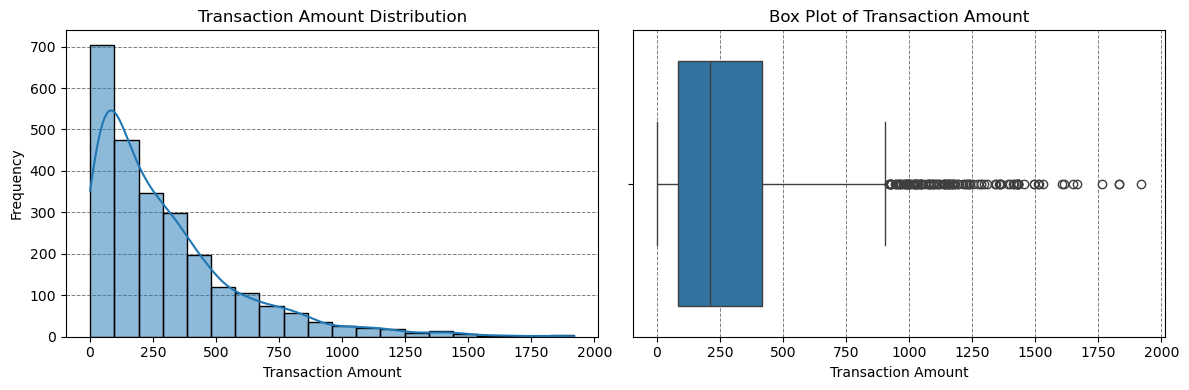

In [9]:
# distribution of transaction amounts across the sample population



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['TransactionAmount'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['TransactionAmount'], ax=axes[1])
axes[1].set_title('Box Plot of Transaction Amount')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()




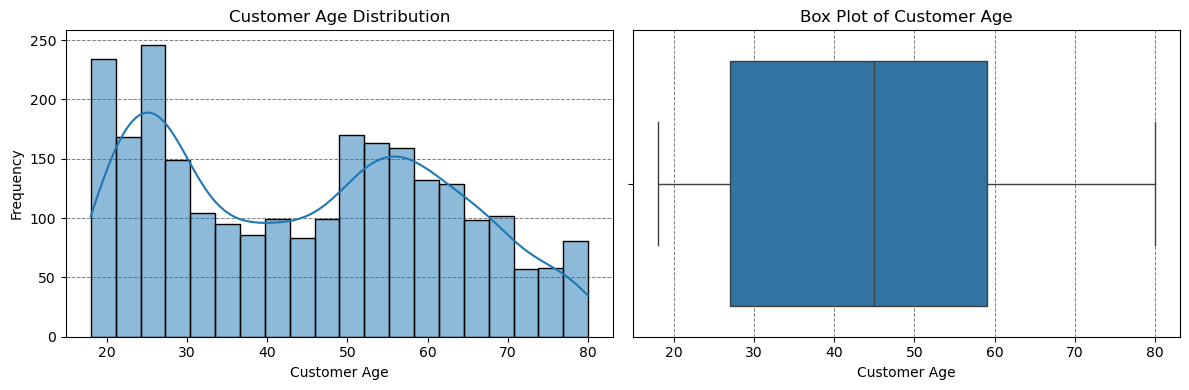


Summary Statistics for Customer Age:
 count    2512.000000
mean       44.673965
std        17.792198
min        18.000000
25%        27.000000
50%        45.000000
75%        59.000000
max        80.000000
Name: CustomerAge, dtype: float64


In [10]:
# Average age of the customers, and how much does the age vary within the customer base


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CustomerAge'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Customer Age')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['CustomerAge'], ax=axes[1])
axes[1].set_title('Box Plot of Customer Age')
axes[1].set_xlabel('Customer Age')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print('\nSummary Statistics for Customer Age:\n', df['CustomerAge'].describe())


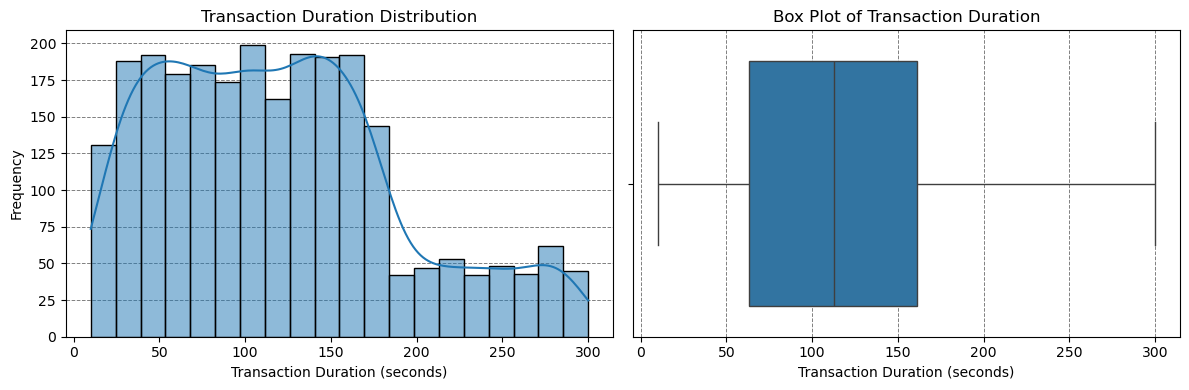


Summary Statistics for Transaction Duration:
 count    2512.000000
mean      119.643312
std        69.963757
min        10.000000
25%        63.000000
50%       112.500000
75%       161.000000
max       300.000000
Name: TransactionDuration, dtype: float64


In [11]:
#General distribution of transaction durations in the dataset

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['TransactionDuration'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Transaction Duration Distribution')
axes[0].set_xlabel('Transaction Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['TransactionDuration'], ax=axes[1])
axes[1].set_title('Box Plot of Transaction Duration')
axes[1].set_xlabel('Transaction Duration (seconds)')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print('\nSummary Statistics for Transaction Duration:\n', df['TransactionDuration'].describe())


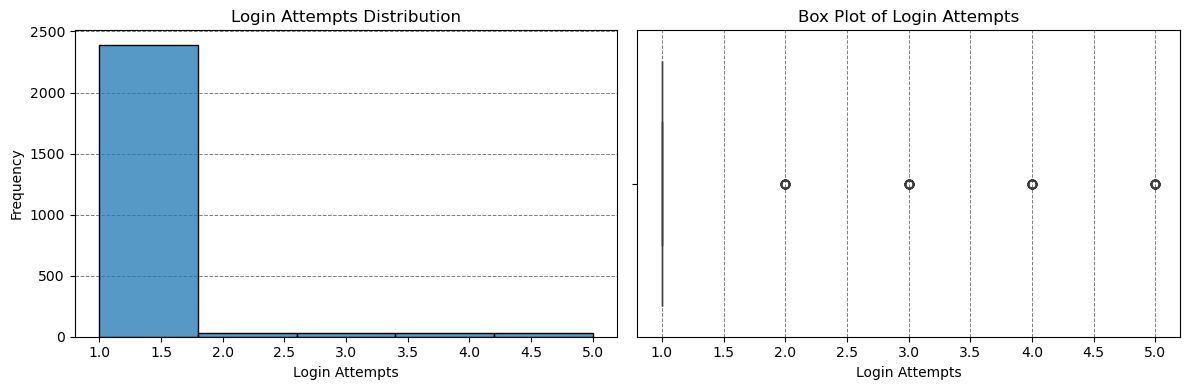


Summary Statistics for Login Attempts:
 count    2512.000000
mean        1.124602
std         0.602662
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: LoginAttempts, dtype: float64


In [12]:
#General distribution of login attempts associate with transaction in the dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['LoginAttempts'], bins=5, kde=False, ax=axes[0])  # bins kept at 5
axes[0].set_title('Login Attempts Distribution')
axes[0].set_xlabel('Login Attempts')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['LoginAttempts'], ax=axes[1])
axes[1].set_title('Box Plot of Login Attempts')
axes[1].set_xlabel('Login Attempts')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print('\nSummary Statistics for Login Attempts:\n', df['LoginAttempts'].describe())


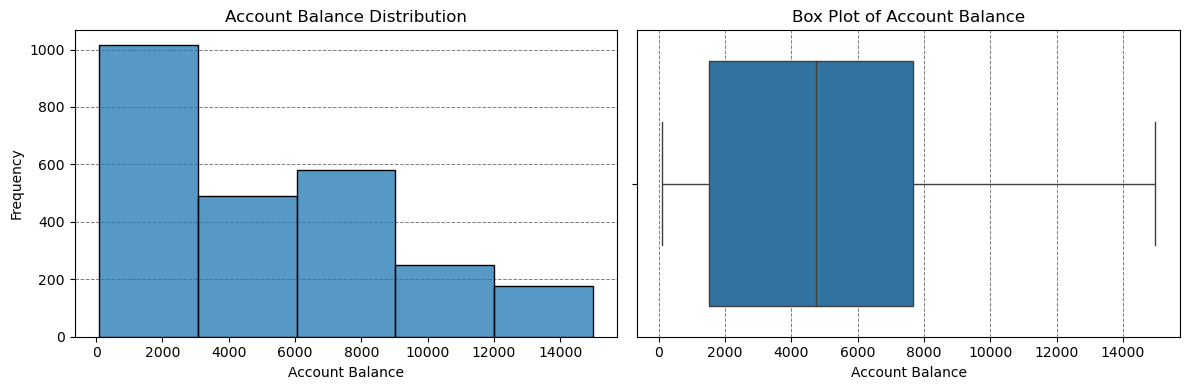


Summary Statistics for Account Balance:
 count     2512.000000
mean      5114.302966
std       3900.942499
min        101.250000
25%       1504.370000
50%       4735.510000
75%       7678.820000
max      14977.990000
Name: AccountBalance, dtype: float64


In [13]:
#OverAll diostribution of Account Balances 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['AccountBalance'], bins=5, kde=False, ax=axes[0])  # bins kept at 5
axes[0].set_title('Account Balance Distribution')
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['AccountBalance'], ax=axes[1])
axes[1].set_title('Box Plot of Account Balance')
axes[1].set_xlabel('Account Balance')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print('\nSummary Statistics for Account Balance:\n', df['AccountBalance'].describe())


In [14]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
Categorical Columns: ['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']


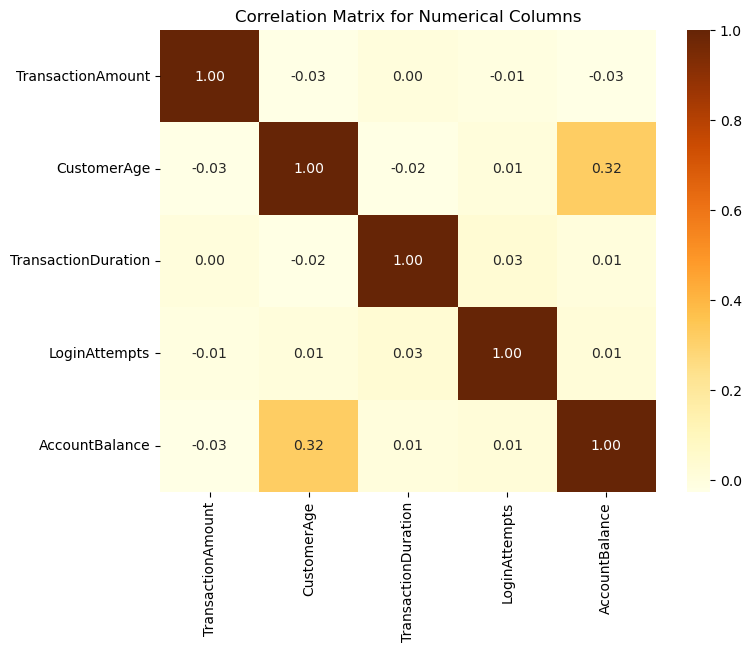

In [15]:
# Define the YlOrBr colormap
cmap = "YlOrBr"

# Display correlation matrix for numerical columns
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=cmap, fmt=".2f")
plt.title('Correlation Matrix for Numerical Columns')
plt.show()

In [16]:
#distribution of transaction type [Credit / Debit]

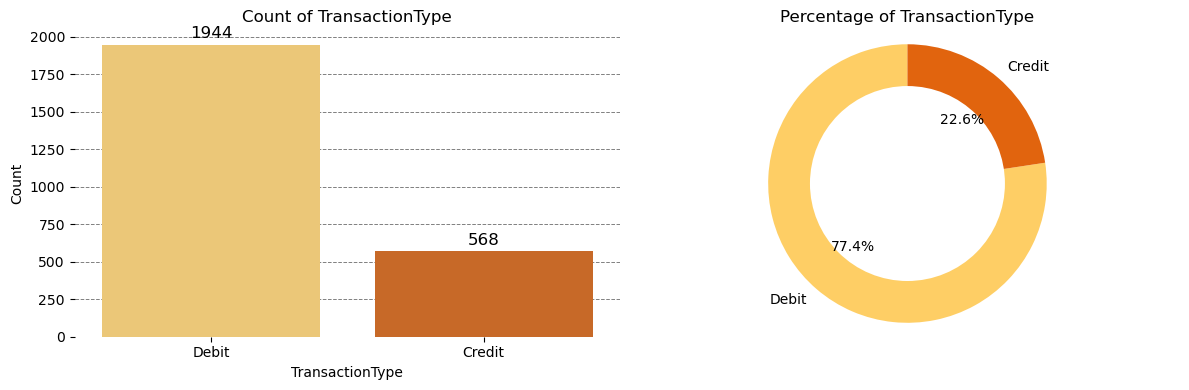

In [17]:
def plot_categorical_distribution(df, feature, palette="YlOrBr"):
    num_categories = len(df[feature].unique())

    custom_palette = sns.color_palette(palette, num_categories)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x=feature, data=df, ax=axes[0], palette=custom_palette)
    axes[0].set_title(f'Count of {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')

    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='baseline',
                         color='black', fontsize=12,
                         xytext=(0, 5),
                         textcoords='offset points')

    axes[0].set_axisbelow(True)
    axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
    sns.despine(left=True, bottom=True)

    # Pie Chart
    feature_counts = df[feature].value_counts()
    wedges, texts, autotexts = axes[1].pie(
        feature_counts,
        labels=feature_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=custom_palette
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')  
    fig.gca().add_artist(centre_circle)
    axes[1].set_title(f'Percentage of {feature}')
    axes[1].axis('equal')  
    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df, 'TransactionType')

In [18]:
#Distribution of Transaction Channels in the dataset

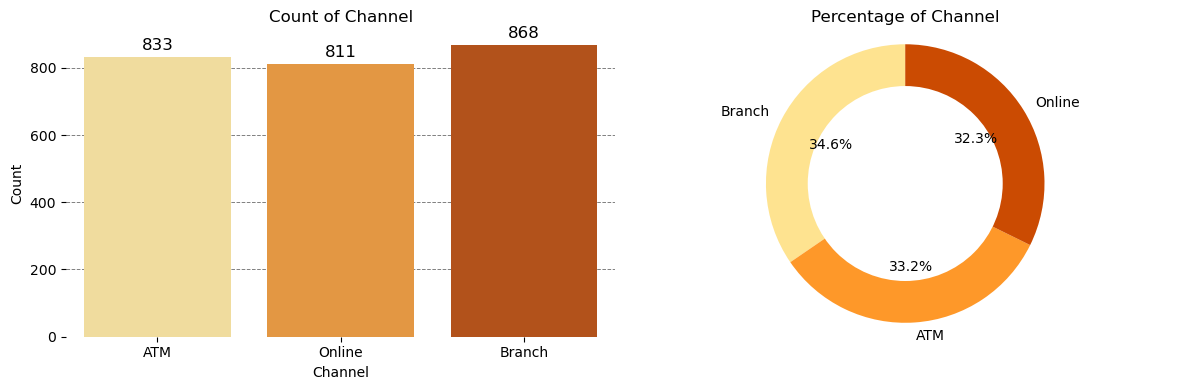

In [19]:
plot_categorical_distribution(df, 'Channel')

In [20]:
# Distribution of customer occupations represented

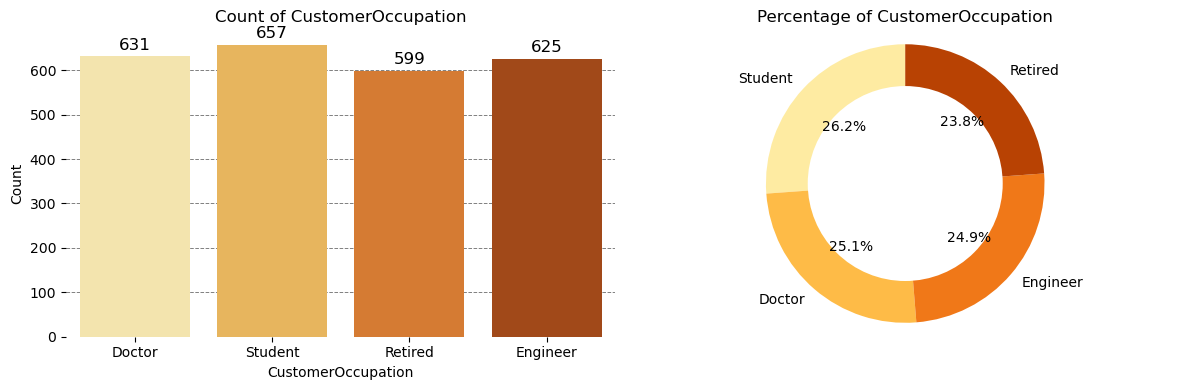

In [21]:
plot_categorical_distribution(df, 'CustomerOccupation')

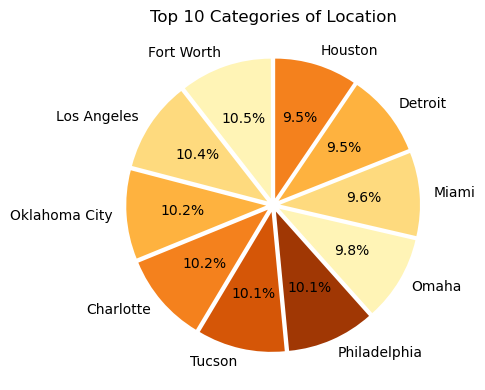

In [22]:
#How concentrated are transactions in Top Locations
def plot_top_categories_pie_chart(column_name, data=df, palette='YlOrBr'):
    plt.figure(figsize=(8, 4))  

    top_categories = data[column_name].value_counts().nlargest(10)

    top_categories.plot.pie(autopct='%1.1f%%', colors=sns.color_palette(palette),
                             startangle=90, explode=[0.05] * len(top_categories))

    plt.title(f'Top 10 Categories of {column_name}')
    plt.ylabel('')  
    plt.tight_layout()
    plt.show()

plot_top_categories_pie_chart('Location')

In [23]:
location_stats = df.groupby('Location')['TransactionAmount'].agg(['count', 'mean', 'median'])
print(location_stats.nlargest(10, 'count')) # Top 10 locations by transaction count

               count        mean  median
Location                                
Fort Worth        70  296.810571  240.41
Los Angeles       69  285.155797  170.19
Charlotte         68  260.039118  185.15
Oklahoma City     68  319.353529  226.50
Philadelphia      67  290.586866  177.05
Tucson            67  305.369552  214.83
Omaha             65  283.143846  178.91
Miami             64  265.144219  168.07
Detroit           63  327.139048  235.40
Houston           63  308.200794  224.19


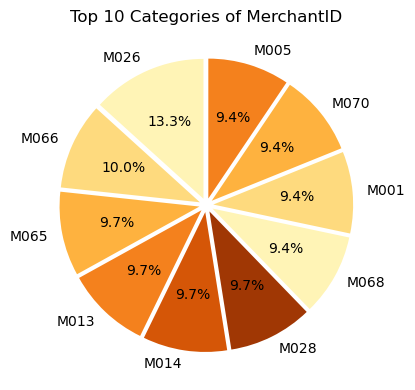

In [24]:
#How concentrated are transactions among top 10 merchants
plot_top_categories_pie_chart('MerchantID')

In [25]:
merchant_stats = df.groupby('MerchantID')['TransactionAmount'].agg(['count', 'mean', 'median'])
print(merchant_stats.nlargest(10, 'count')) # Top 10 merchants by transaction count, with amount stats

            count        mean   median
MerchantID                            
M026           45  308.114444  185.990
M066           34  351.433824  244.210
M013           33  315.646970  236.810
M014           33  286.909091  256.800
M028           33  312.615758  180.940
M065           33  240.501818  166.550
M001           32  260.002500  145.850
M005           32  346.872813  275.325
M015           32  298.023438  171.250
M068           32  302.502187  269.905


In [26]:
## What is the average transaction amount for credit transactions compared to debit transactions?

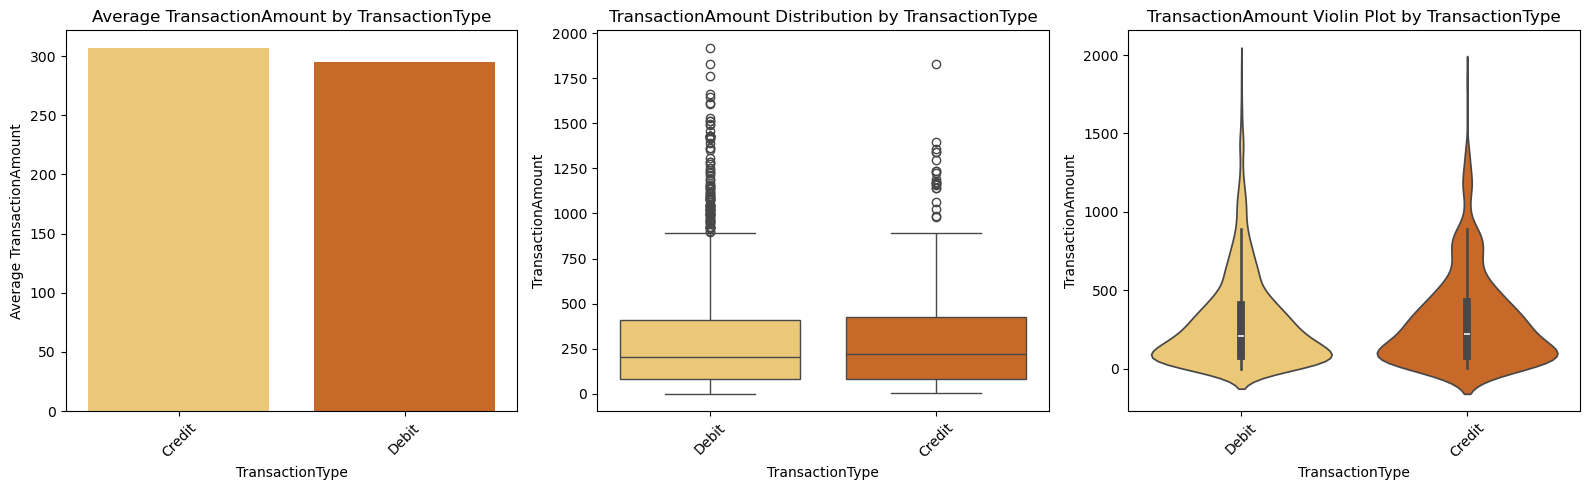

In [27]:
def plot_categorical_relationships(column_name, data=df, palette='YlOrBr'):
    plt.figure(figsize=(16, 5))

    # Bar Plot
    plt.subplot(1, 3, 1)
    avg_transaction = data.groupby(column_name)['TransactionAmount'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_transaction.index, y=avg_transaction.values, palette=palette)
    plt.title(f'Average TransactionAmount by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Average TransactionAmount')
    plt.xticks(rotation=45)

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=column_name, y='TransactionAmount', data=data, palette=palette)
    plt.title(f'TransactionAmount Distribution by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('TransactionAmount')
    plt.xticks(rotation=45)

    # Violin Plot
    plt.subplot(1, 3, 3)
    sns.violinplot(x=column_name, y='TransactionAmount', data=data, palette=palette)
    plt.title(f'TransactionAmount Violin Plot by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('TransactionAmount')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

plot_categorical_relationships('TransactionType')

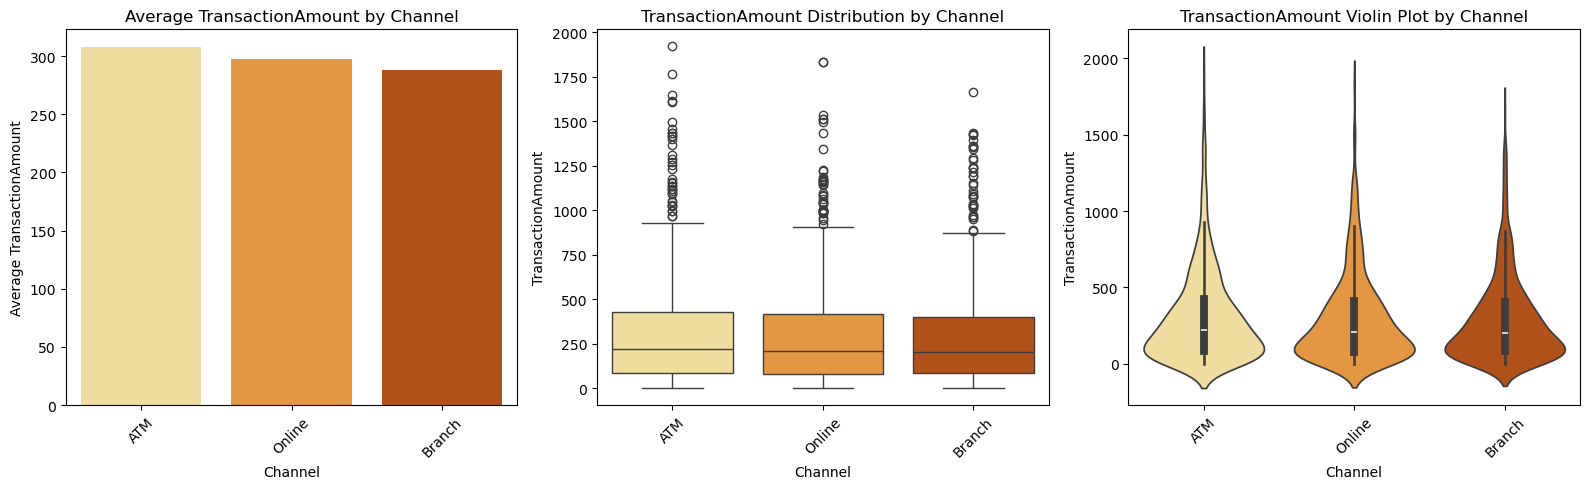

In [28]:
## What is the average transaction amount for each transaction channel (e.g., Online, ATM, Branch)? 
plot_categorical_relationships('Channel')

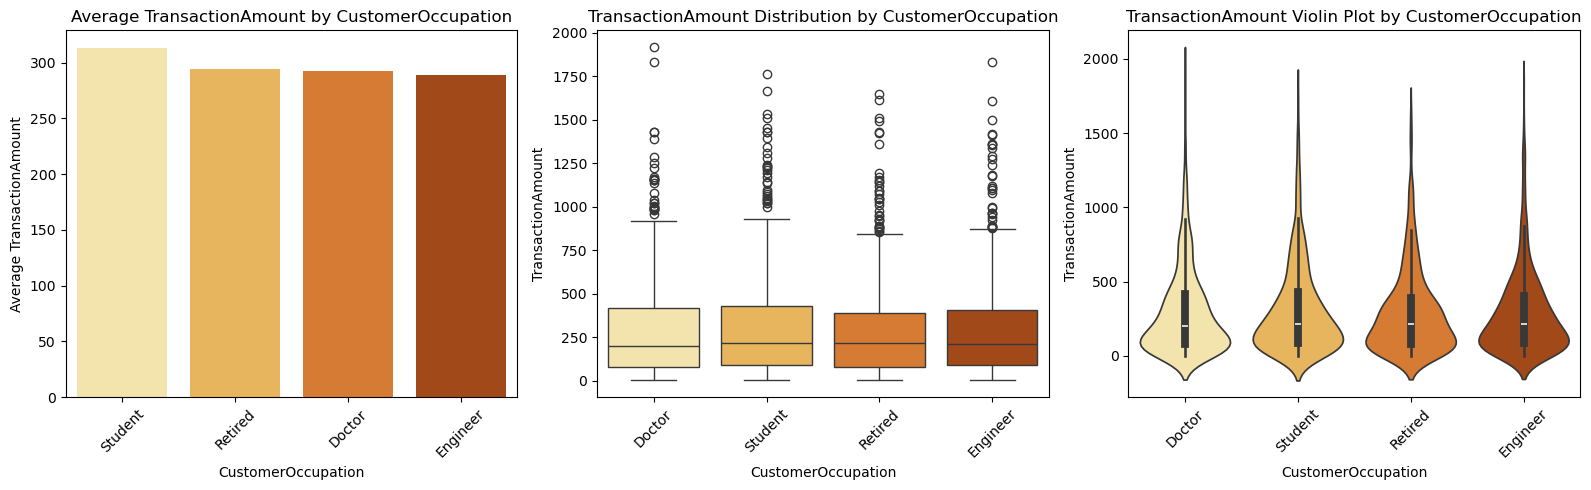

In [29]:
## What is the average transaction amount for each customer occupation category (e.g., Doctor, Engineer, Student, Retired)?
plot_categorical_relationships('CustomerOccupation')

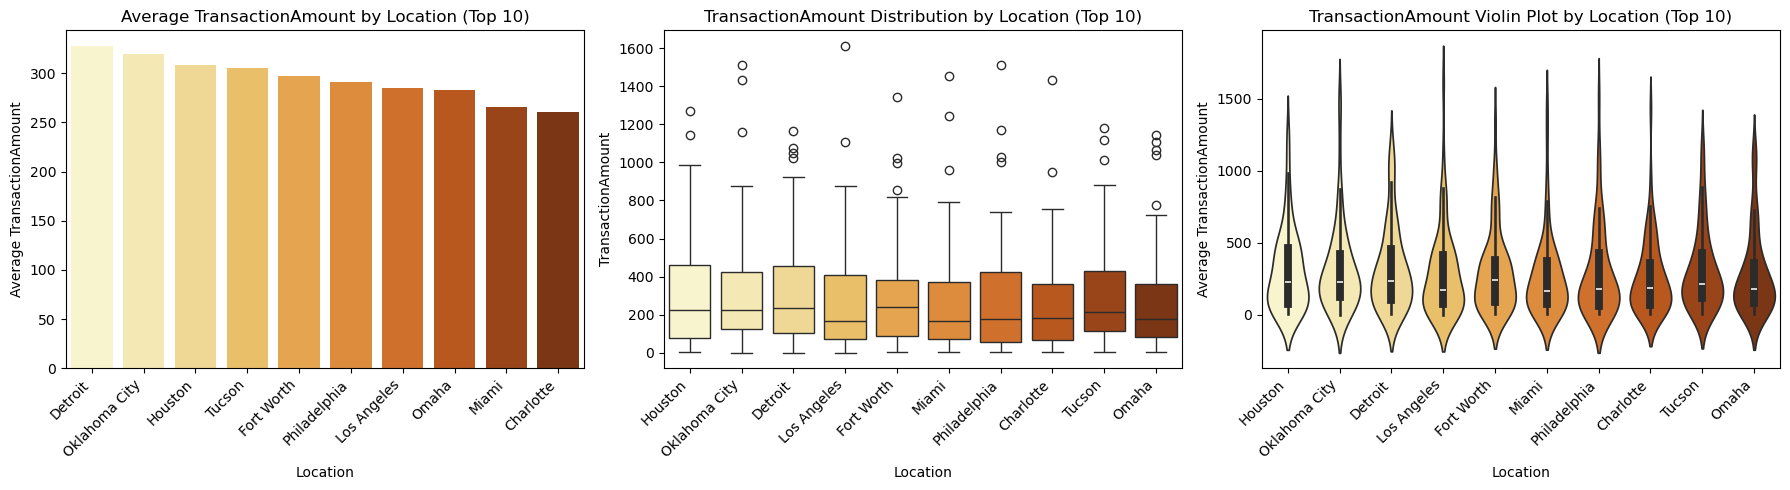

In [30]:
## What are the average transaction amounts in each of the top 10 most frequent locations?
def plot_categorical_relationships_improved(column_name, data=df, top_n=15, palette='YlOrBr'):
    top_categories = data[column_name].value_counts().index[:top_n]
    filtered_data = data[data[column_name].isin(top_categories)]

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    avg_transaction = filtered_data.groupby(column_name)['TransactionAmount'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_transaction.index, y=avg_transaction.values, palette=palette)
    plt.title(f'Average TransactionAmount by {column_name} (Top {top_n})')
    plt.xlabel(column_name)
    plt.ylabel('Average TransactionAmount')
    plt.xticks(rotation=45, ha='right')  

    plt.subplot(1, 3, 2)
    sns.boxplot(x=column_name, y='TransactionAmount', data=filtered_data, palette=palette)
    plt.title(f'TransactionAmount Distribution by {column_name} (Top {top_n})')
    plt.xlabel(column_name)
    plt.ylabel('TransactionAmount')
    plt.xticks(rotation=45, ha='right')

    # Violin Plot
    plt.subplot(1, 3, 3)
    sns.violinplot(x=column_name, y='TransactionAmount', data=filtered_data, palette=palette)
    plt.title(f'TransactionAmount Violin Plot by {column_name} (Top {top_n})')
    plt.xlabel(column_name)
    plt.ylabel('Average TransactionAmount')
    plt.xticks(rotation=45, ha='right')  

    plt.tight_layout()
    plt.show()

plot_categorical_relationships_improved('Location', top_n=10)

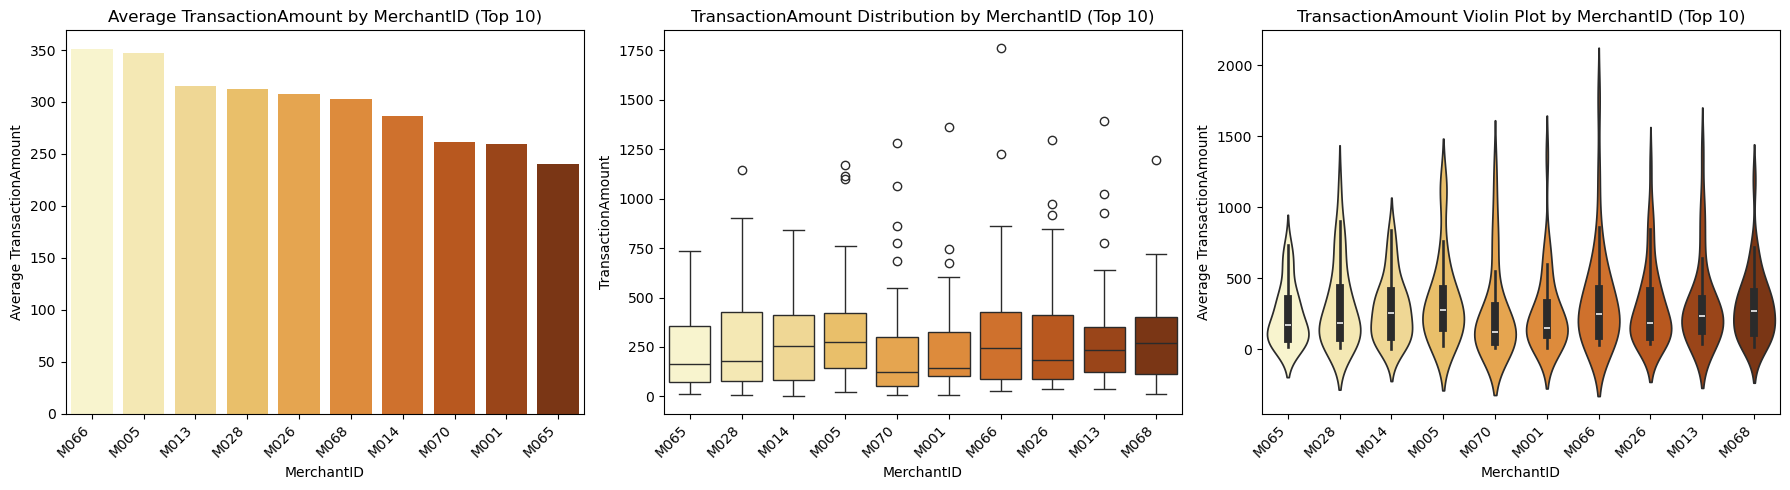

In [31]:
## What are the average transaction amounts for each of the top 10 most frequent merchants (identified by MerchantID)?
plot_categorical_relationships_improved('MerchantID', top_n=10)

Number of high-value transactions (top 5%): 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
74,TX000075,AC00265,1212.51,2023-10-04 16:36:29,Debit,Indianapolis,D000231,193.83.0.183,M036,Branch,20,Student,24,1,605.95,2024-11-04 08:06:51
82,TX000083,AC00236,922.55,2023-01-23 16:32:48,Debit,Detroit,D000206,21.97.154.92,M004,ATM,63,Retired,87,1,4715.84,2024-11-04 08:11:07
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,Austin,D000574,165.114.224.47,M012,Online,54,Engineer,30,1,8654.28,2024-11-04 08:06:53
110,TX000111,AC00068,1045.22,2023-11-22 16:13:39,Debit,Columbus,D000400,77.7.223.184,M077,ATM,53,Retired,73,1,1829.90,2024-11-04 08:07:35
129,TX000130,AC00320,1036.66,2023-07-11 16:39:53,Debit,San Antonio,D000015,53.218.177.171,M062,Branch,58,Doctor,144,1,5541.57,2024-11-04 08:09:24


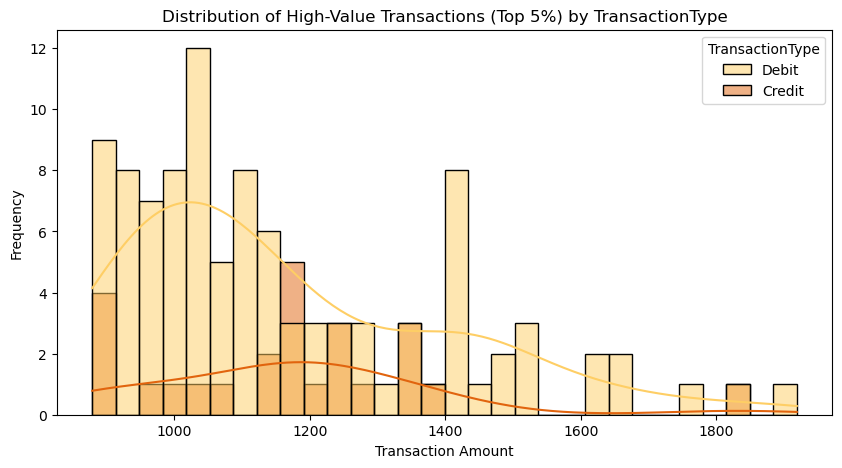

In [32]:
## What is the distribution of transaction amounts specifically within the top 5% of transactions? 
high_value_threshold = df['TransactionAmount'].quantile(0.95)
high_value_transactions = df[df['TransactionAmount'] > high_value_threshold]
print(f"Number of high-value transactions (top 5%): {len(high_value_transactions)}")
display(high_value_transactions.head())

# Plot high-value transactions
plt.figure(figsize=(10, 5))
sns.histplot(data=high_value_transactions, x='TransactionAmount', bins=30, kde=True, hue='TransactionType', palette='YlOrBr')
plt.title('Distribution of High-Value Transactions (Top 5%) by TransactionType')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')  
plt.show()


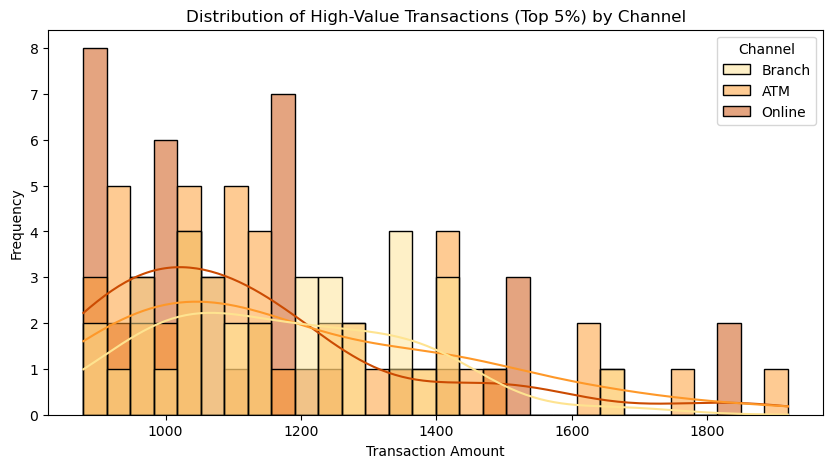

In [33]:
## What is the distribution of high-value transaction amounts for each transaction channel (Online, ATM, Branch)?
# Plotting high-value transactions with 'Channel' as hue
plt.figure(figsize=(10, 5))
sns.histplot(data=high_value_transactions, x='TransactionAmount', bins=30, kde=True, hue='Channel', palette='YlOrBr')
plt.title('Distribution of High-Value Transactions (Top 5%) by Channel')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency') 
plt.show()


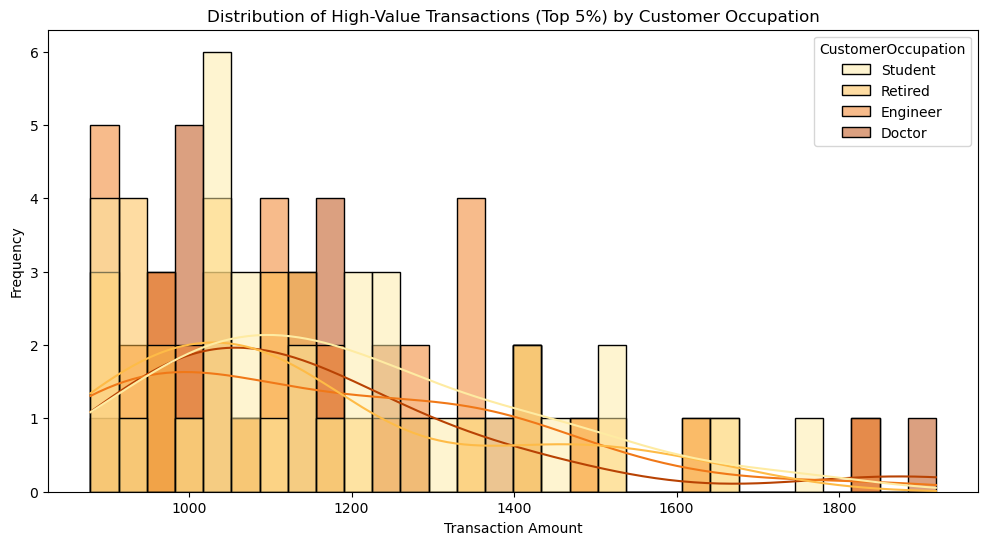

In [34]:
## What is the distribution of high-value transaction amounts for each customer occupation represented in the dataset?
# Plotting high-value transactions with 'CustomerOccupation' as hue
plt.figure(figsize=(12, 6))  
sns.histplot(data=high_value_transactions, x='TransactionAmount', bins=30, kde=True, hue='CustomerOccupation', palette='YlOrBr')
plt.title('Distribution of High-Value Transactions (Top 5%) by Customer Occupation')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')  
plt.show()


Number of frequent transactions (within 1 hour): 16


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeDifference
95,TX000096,AC00010,508.68,2023-06-26 16:16:50,Credit,Mesa,D000622,193.108.17.115,M048,Branch,51,Engineer,127,1,7708.41,2024-11-04 08:09:32,505.0
1258,TX001259,AC00020,603.23,2023-08-24 17:34:13,Debit,Detroit,D000238,38.210.156.148,M017,Branch,28,Student,48,1,117.98,2024-11-04 08:08:18,2812.0
2497,TX002498,AC00030,348.17,2023-05-10 17:56:31,Debit,El Paso,D000269,82.51.236.134,M072,ATM,21,Student,181,1,1887.84,2024-11-04 08:11:06,394.0
496,TX000497,AC00114,286.50,2023-10-23 16:58:04,Credit,Boston,D000602,16.128.130.153,M097,Branch,30,Engineer,60,1,8517.95,2024-11-04 08:09:17,451.0
2341,TX002342,AC00144,97.73,2023-05-29 17:55:23,Debit,Sacramento,D000038,135.29.211.116,M018,Branch,69,Doctor,156,1,7885.21,2024-11-04 08:08:27,2480.0


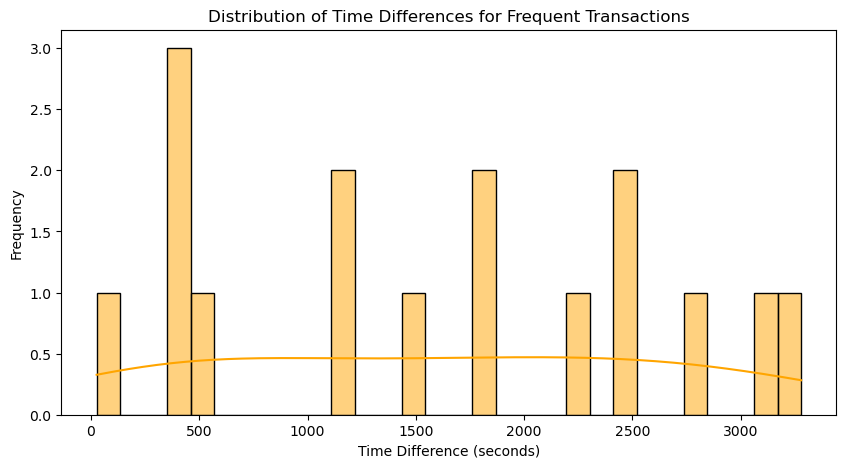

In [35]:
## What is the distribution of time differences between frequent transactions?
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df_sorted = df.sort_values(by=['AccountID', 'TransactionDate'])
df_sorted['TimeDifference'] = df_sorted.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds()

# Identify frequent transactions with short intervals
short_interval_threshold = 3600  # 1 hour in seconds
frequent_transactions = df_sorted[df_sorted['TimeDifference'] <= short_interval_threshold]

print(f"Number of frequent transactions (within 1 hour): {len(frequent_transactions)}")
display(frequent_transactions.head())

# Plot the distribution of time differences for visualization
plt.figure(figsize=(10, 5))
sns.histplot(frequent_transactions['TimeDifference'], bins=30, kde=True, color = "orange")
plt.title('Distribution of Time Differences for Frequent Transactions')
plt.xlabel('Time Difference (seconds)')
plt.ylabel('Frequency')
plt.show()

Number of transactions with large balance changes: 125


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,13382.67
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09,13323.79
34,TX000035,AC00365,255.26,2023-10-27 16:42:49,Credit,San Francisco,D000357,92.214.76.157,M002,Branch,45,Doctor,50,1,14815.87,2024-11-04 08:10:51,15071.13
41,TX000042,AC00480,34.02,2023-01-09 16:13:21,Debit,Philadelphia,D000627,109.105.179.186,M046,Online,38,Doctor,19,1,14214.48,2024-11-04 08:11:45,14180.46
42,TX000043,AC00120,241.42,2023-04-20 18:57:43,Credit,Charlotte,D000198,60.89.202.192,M044,Online,57,Doctor,116,1,13357.02,2024-11-04 08:09:03,13598.44


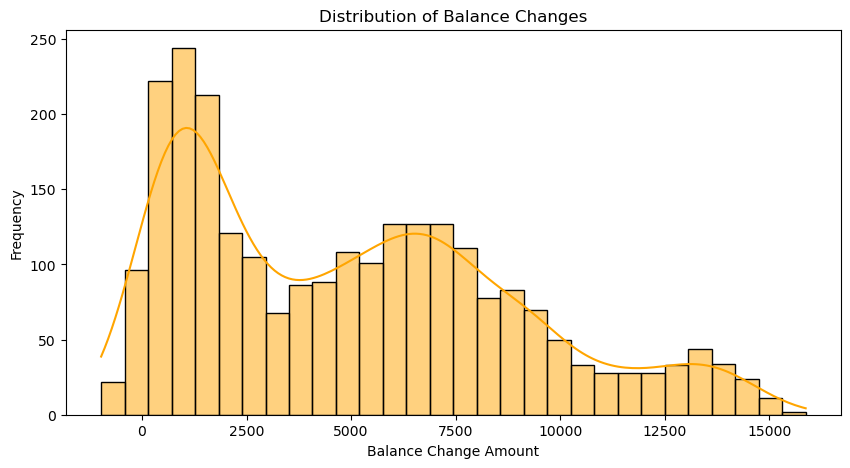

In [36]:
## What is the overall distribution of balance changes in the dataset?
# Calculate change in AccountBalance for each transaction, considering TransactionType
df['BalanceChange'] = df.apply(
    lambda row: row['AccountBalance'] - row['TransactionAmount'] if row['TransactionType'] == 'Debit' 
    else row['AccountBalance'] + row['TransactionAmount'],
    axis=1
)

# Identify large balance changes based on threshold (e.g., 2 standard deviations)
balance_change_threshold = df['BalanceChange'].mean() + 2 * df['BalanceChange'].std()
large_balance_changes = df[df['BalanceChange'].abs() > balance_change_threshold]
print(f"Number of transactions with large balance changes: {len(large_balance_changes)}")
display(large_balance_changes.head())

# Visualize balance changes
plt.figure(figsize=(10, 5))
sns.histplot(df['BalanceChange'], bins=30, kde=True, color = "orange")
plt.title('Distribution of Balance Changes')
plt.xlabel('Balance Change Amount')
plt.ylabel('Frequency') 
plt.show()


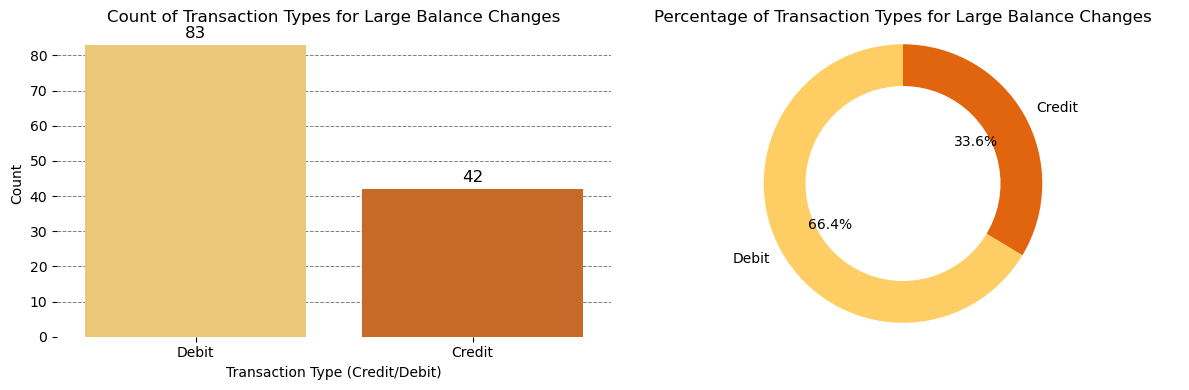

In [37]:
## What is the proportion of credit versus debit transactions associated with large balance changes? 
# Group large balance changes by TransactionType and count occurrences
transaction_type_counts = large_balance_changes['TransactionType'].value_counts()
#print("Transaction Type Distribution for Large Balance Changes:\n", transaction_type_counts)

# Calculate percentages
transaction_type_percentages = large_balance_changes['TransactionType'].value_counts(normalize=True) * 100
#print("\nTransaction Type Percentages for Large Balance Changes:\n", transaction_type_percentages)

custom_palette = sns.color_palette("YlOrBr", 2)  
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='TransactionType', data=large_balance_changes, ax=axes[0], palette=custom_palette)
axes[0].set_title('Count of Transaction Types for Large Balance Changes')
axes[0].set_xlabel('Transaction Type (Credit/Debit)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline',
                     color='black', fontsize=12,
                     xytext=(0, 5),
                     textcoords='offset points')

axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
sns.despine(left=True, bottom=True)

transaction_type_counts = large_balance_changes['TransactionType'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    transaction_type_counts,
    labels=transaction_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_palette
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
axes[1].set_title('Percentage of Transaction Types for Large Balance Changes')
axes[1].axis('equal')
plt.tight_layout()
plt.show()

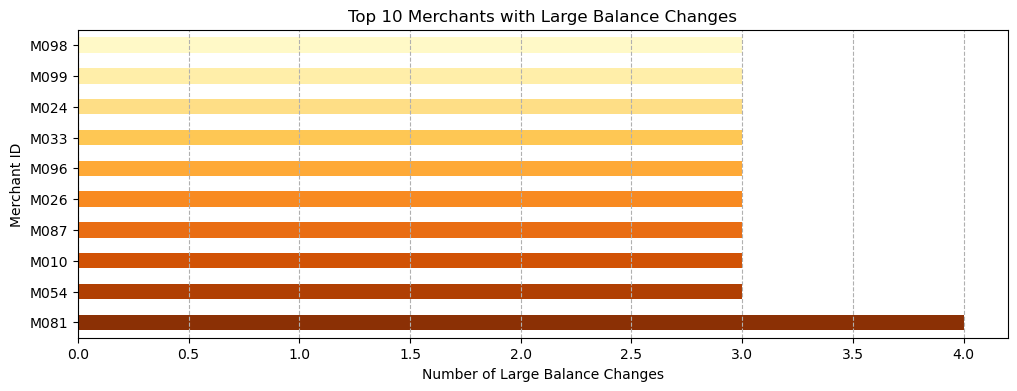

In [38]:
## Who are the top 10 merchants (by MerchantID) associated with the ***largest number*** of large balance changes?
# Merchants
merchant_counts = large_balance_changes['MerchantID'].value_counts().nlargest(10)  
# print("Top 10 Merchants with Large Balance Changes:\n", merchant_counts)

plt.figure(figsize=(12, 4))  
merchant_counts.plot(kind='barh', color=sns.color_palette("YlOrBr_r", 10)) 
plt.title('Top 10 Merchants with Large Balance Changes')
plt.xlabel('Number of Large Balance Changes')
plt.ylabel('Merchant ID')
plt.grid(axis='x', linestyle='--') 
plt.show()

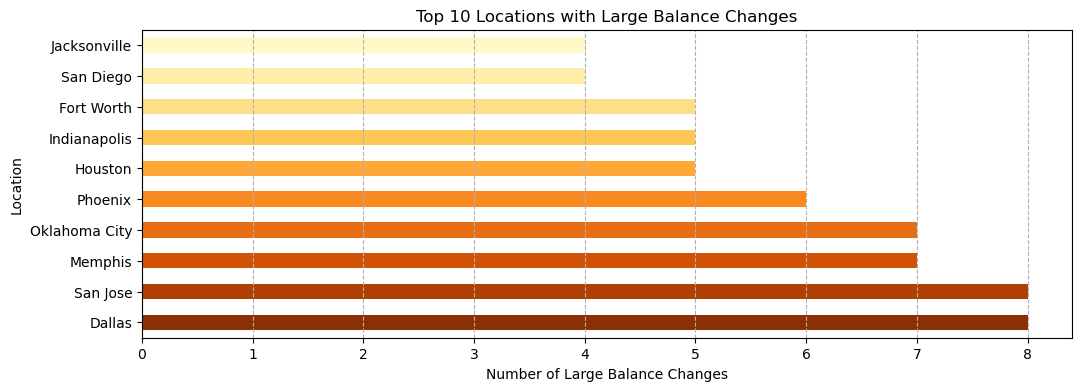

In [39]:
## What are the top 10 locations associated with the ***largest number*** of large balance changes?
# Locations
location_counts = large_balance_changes['Location'].value_counts().nlargest(10) 
# print("\nTop 10 Locations with Large Balance Changes:\n", location_counts)

plt.figure(figsize=(12, 4)) 
location_counts.plot(kind='barh', color=sns.color_palette("YlOrBr_r", 10))
plt.title('Top 10 Locations with Large Balance Changes')
plt.xlabel('Number of Large Balance Changes')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--')
plt.show()

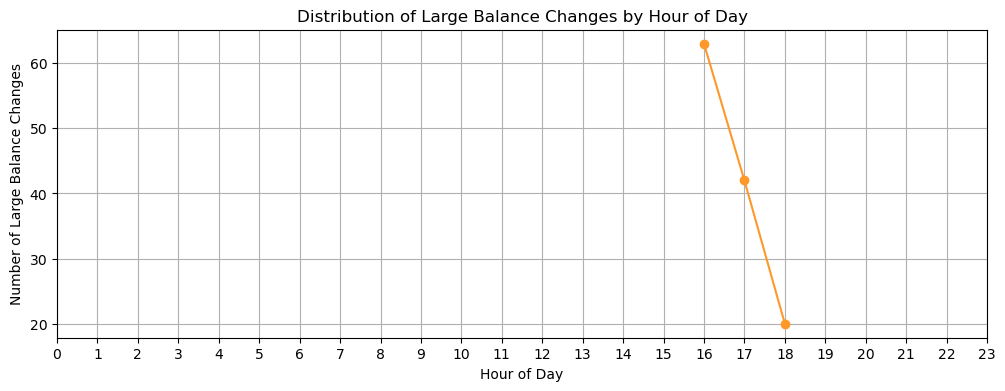

In [40]:
## What is the distribution of large balance changes across the hours of the day? Are there specific times when large balance changes are more frequent?
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Extract hour and day of week
large_balance_changes['TransactionHour'] = large_balance_changes['TransactionDate'].dt.hour
large_balance_changes['TransactionDayOfWeek'] = large_balance_changes['TransactionDate'].dt.day_name()

# Analyze by Hour
hour_counts = large_balance_changes['TransactionHour'].value_counts().sort_index()
# print("Distribution by Hour:\n", hour_counts)

plt.figure(figsize=(12, 4))  
plt.plot(hour_counts.index, hour_counts.values, color=sns.color_palette("YlOrBr", 1)[0], marker='o') 
plt.title('Distribution of Large Balance Changes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Large Balance Changes')
plt.xticks(range(24))
plt.grid(True)
plt.show()

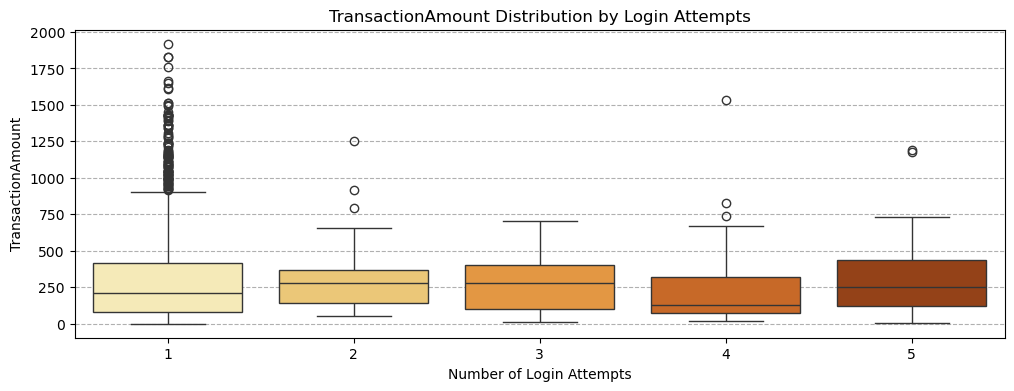

In [41]:
## What is the relationship between the number of login attempts and the distribution of transaction amounts?
# Relationship between Login Attempts and TransactionAmount
plt.figure(figsize=(12, 4))
sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=df, palette='YlOrBr')
plt.title('TransactionAmount Distribution by Login Attempts')
plt.xlabel('Number of Login Attempts')
plt.ylabel('TransactionAmount')
plt.grid(axis='y', linestyle='--') 
plt.show()


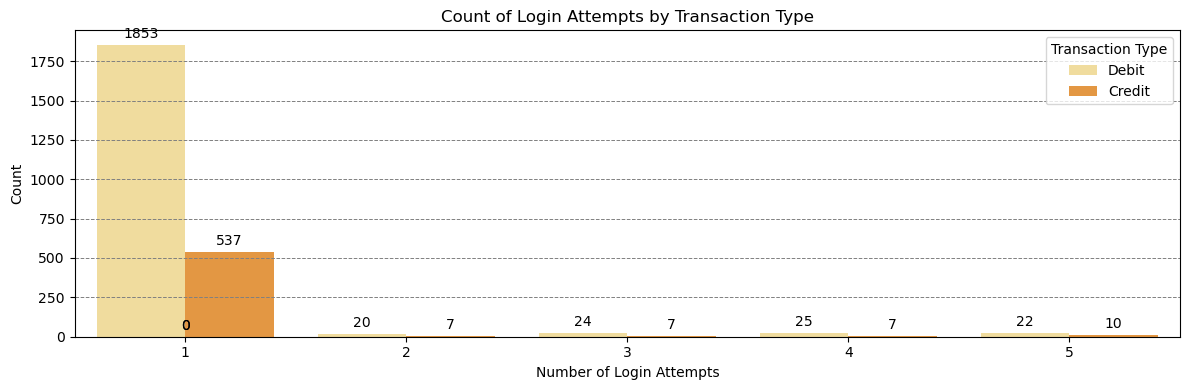

In [42]:
## What is the distribution of login attempts for each transaction type (Credit/Debit)?
#Create a count plot of Login Attempts by TransactionType
custom_palette = sns.color_palette("YlOrBr", 3) 
plt.figure(figsize=(12, 4))
sns.countplot(x='LoginAttempts', hue='TransactionType', data=df, palette=custom_palette)
plt.title('Count of Login Attempts by Transaction Type')
plt.xlabel('Number of Login Attempts')
plt.ylabel('Count')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
plt.legend(title='Transaction Type')

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

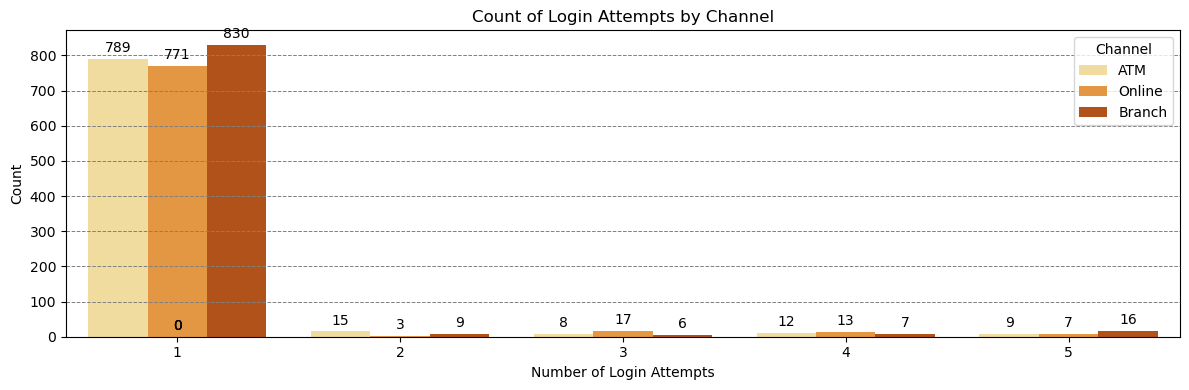

In [43]:
## What is the distribution of login attempts for each channel (Online, ATM, Branch, etc.)? 
# Create a count plot of Login Attempts by Channel
custom_palette = sns.color_palette("YlOrBr", 3)  
plt.figure(figsize=(12, 4))
sns.countplot(x='LoginAttempts', hue='Channel', data=df, palette=custom_palette)
plt.title('Count of Login Attempts by Channel')
plt.xlabel('Number of Login Attempts')
plt.ylabel('Count')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
plt.legend(title='Channel')

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

In [44]:
## How many transactions involve more than one login attempt? 
# Transactions with more than onelogin attempt
high_login_attempts = df[df['LoginAttempts'] > 1]
print(f"Number of transactions with more than one login attempt: {len(high_login_attempts)}")
display(high_login_attempts.head())

Number of transactions with more than one login attempt: 122


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange
23,TX000024,AC00453,345.84,2023-05-02 18:25:46,Debit,Fort Worth,D000162,191.82.103.198,M083,Online,22,Student,142,3,1402.50,2024-11-04 08:07:04,1056.66
26,TX000027,AC00441,246.93,2023-04-17 16:37:01,Debit,Miami,D000046,55.154.161.250,M029,ATM,23,Student,158,5,673.35,2024-11-04 08:11:38,426.42
32,TX000033,AC00060,396.45,2023-09-25 16:26:00,Debit,New York,D000621,133.67.250.163,M007,ATM,49,Engineer,168,3,9690.15,2024-11-04 08:11:13,9293.70
38,TX000039,AC00478,795.31,2023-10-12 17:07:40,Debit,Mesa,D000077,49.29.37.185,M048,ATM,66,Doctor,90,2,7914.88,2024-11-04 08:11:17,7119.57
61,TX000062,AC00002,263.99,2023-05-16 16:07:30,Debit,Dallas,D000285,7.146.35.122,M087,Branch,79,Retired,227,2,4175.02,2024-11-04 08:11:03,3911.03


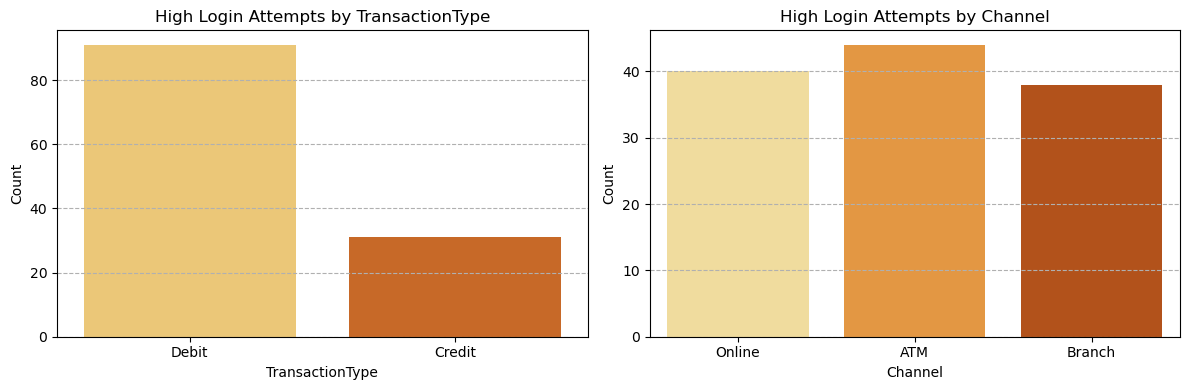

In [45]:
# Analyzing high login attempts with respect to TransactionType and Channel
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=high_login_attempts, x='TransactionType', palette=sns.color_palette("YlOrBr", 2)) 
plt.title('High Login Attempts by TransactionType')
plt.xlabel('TransactionType')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--') 

plt.subplot(1, 2, 2)
sns.countplot(data=high_login_attempts, x='Channel', palette=sns.color_palette("YlOrBr", len(high_login_attempts['Channel'].unique()))) 
plt.title('High Login Attempts by Channel')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--') 

plt.tight_layout()
plt.show()

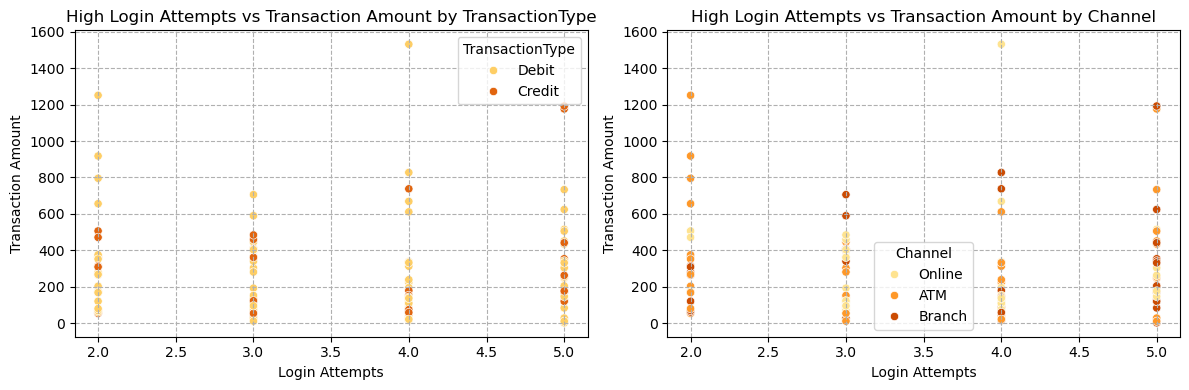

In [46]:
# Transactions with more than one login attempt
high_login_attempts = df[df['LoginAttempts'] > 1]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

sns.scatterplot(data=high_login_attempts, x='LoginAttempts', y='TransactionAmount', hue='TransactionType', palette="YlOrBr", ax=axes[0])
axes[0].set_title('High Login Attempts vs Transaction Amount by TransactionType')
axes[0].set_xlabel('Login Attempts')
axes[0].set_ylabel('Transaction Amount')
axes[0].grid(True, linestyle='--')

sns.scatterplot(data=high_login_attempts, x='LoginAttempts', y='TransactionAmount', hue='Channel', palette="YlOrBr", ax=axes[1])
axes[1].set_title('High Login Attempts vs Transaction Amount by Channel')
axes[1].set_xlabel('Login Attempts')
axes[1].set_ylabel('Transaction Amount')
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

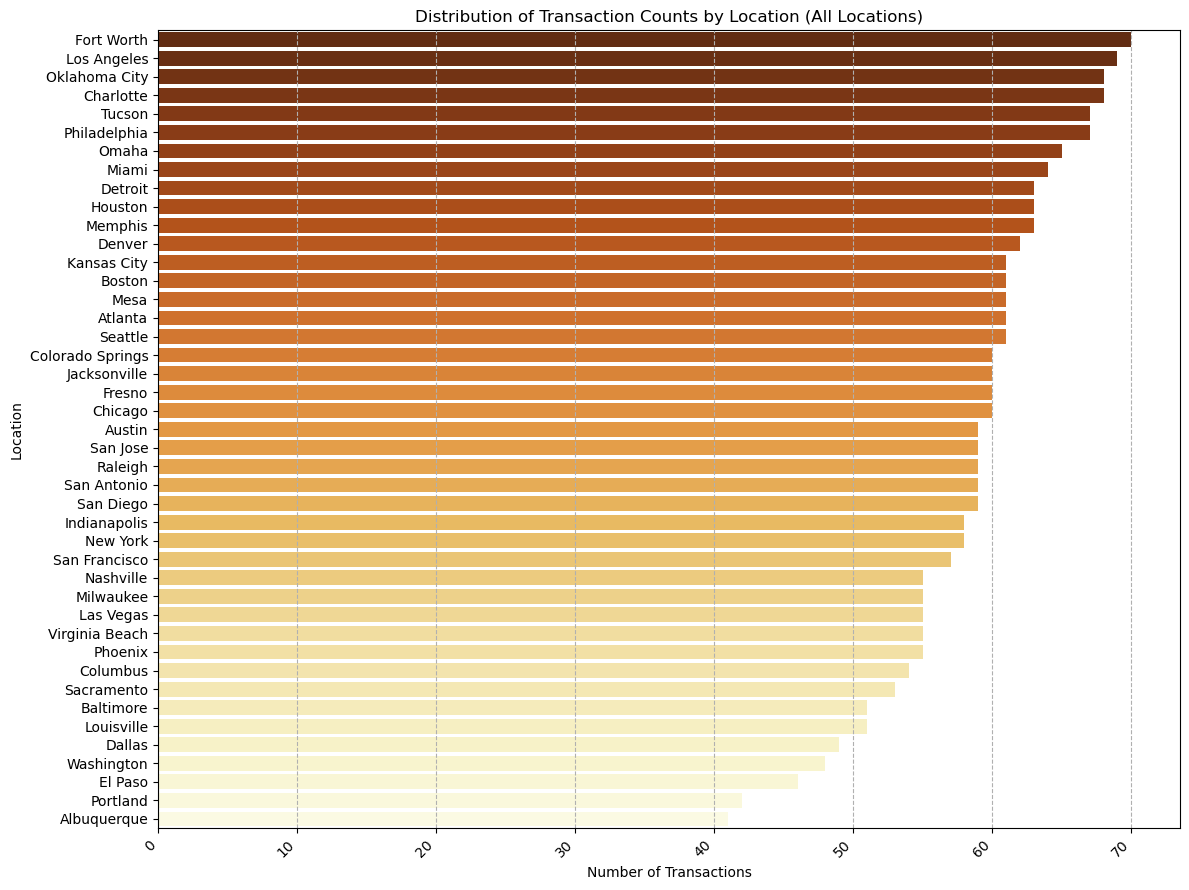

In [47]:
## What are the most frequent locations and the least frequent ones?
# Distribution of Transactions by Location (All Locations)
plt.figure(figsize=(12, 9))  
location_counts = df['Location'].value_counts()
sns.barplot(x=location_counts.values, y=location_counts.index, palette='YlOrBr_r') 
plt.title('Distribution of Transaction Counts by Location (All Locations)')
plt.xlabel('Number of Transactions')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()

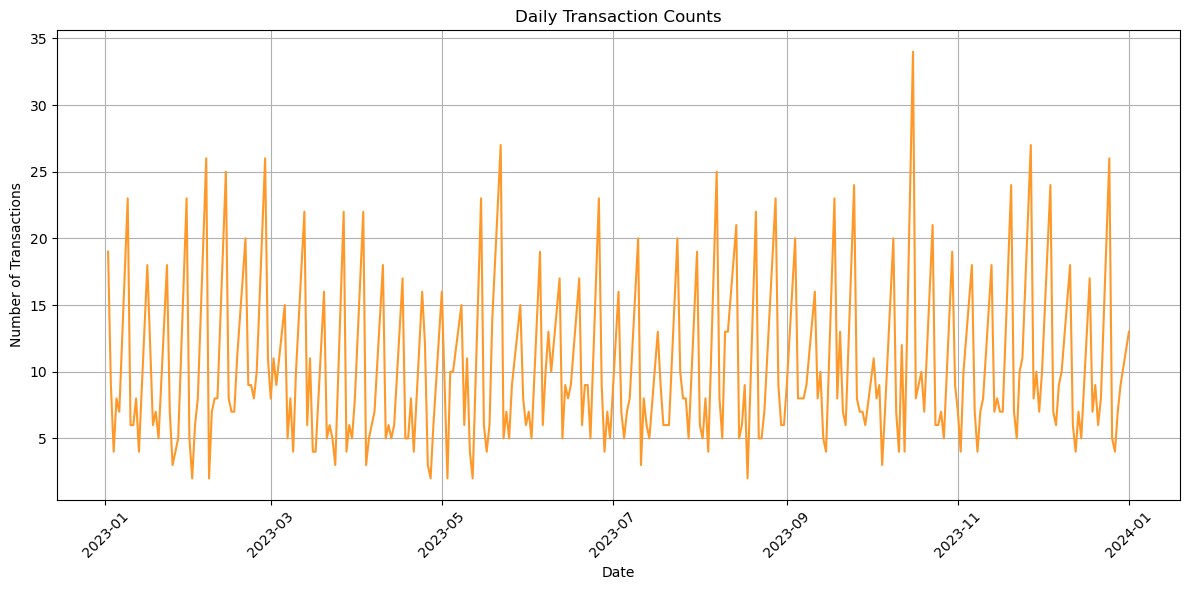

In [48]:
## What is the overall trend in daily transaction counts over the period covered by the data?
# Ensure TransactionDate is in datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

# Group by date and count transactions
daily_transactions = df.groupby(df['TransactionDate'].dt.date).size().reset_index(name='TransactionCount')
daily_transactions['TransactionDate'] = pd.to_datetime(daily_transactions['TransactionDate'])

plt.figure(figsize=(12, 6))  
sns.lineplot(x='TransactionDate', y='TransactionCount', data=daily_transactions, color=sns.color_palette("YlOrBr", 1)[0])
plt.title('Daily Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()

In [49]:
## Is there a significant difference in transaction counts between weekdays and weekends?

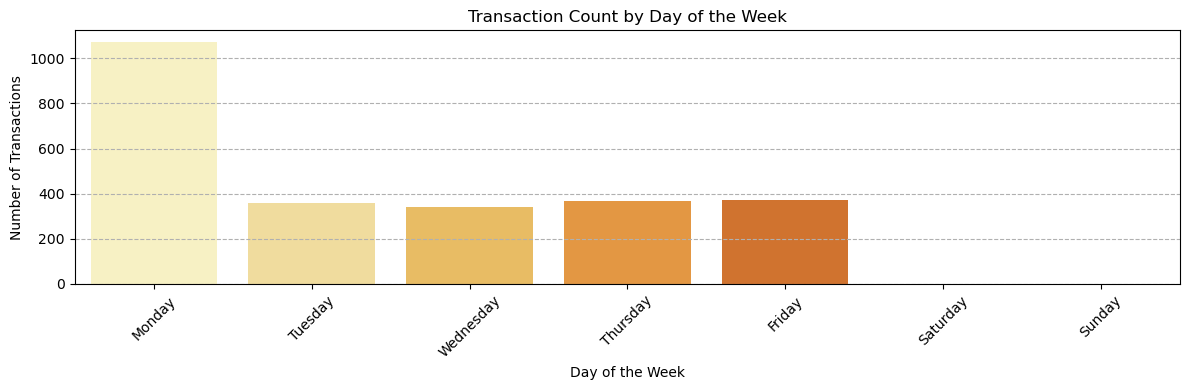

In [50]:
# Extract the day of the week
df['Day_of_Week'] = df['TransactionDate'].dt.day_name()

# Group by day of the week and count transactions
weekday_counts = df['Day_of_Week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='YlOrBr')
plt.title('Transaction Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [51]:
## How many transactions occurred during unusual hours (outside 9 AM - 6 PM)?

In [52]:
df['TransactionHour'] = df['TransactionDate'].dt.hour

# Define unusual hours (outside 9 AM - 6 PM)
unusual_hours = list(range(0, 9)) + list(range(18, 24))

# Filter transactions during unusual hours
unusual_hour_transactions = df[df['TransactionHour'].isin(unusual_hours)]

print(f"Number of transactions during unusual hours: {len(unusual_hour_transactions)}")
display(unusual_hour_transactions.head())

Number of transactions during unusual hours: 377


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,996.06,Monday,18
17,TX000018,AC00359,492.93,2023-12-14 18:32:14,Debit,Columbus,D000432,114.223.129.47,M059,Online,39,Engineer,234,1,5109.97,2024-11-04 08:11:51,4617.04,Thursday,18
19,TX000020,AC00285,71.48,2023-06-08 18:18:50,Credit,Columbus,D000039,120.170.93.69,M039,Online,18,Student,169,1,6568.59,2024-11-04 08:09:20,6640.07,Thursday,18
21,TX000022,AC00014,85.77,2023-08-11 18:31:31,Debit,Las Vegas,D000268,59.132.247.252,M065,Branch,38,Doctor,93,1,9146.19,2024-11-04 08:08:13,9060.42,Friday,18
22,TX000023,AC00095,52.20,2023-06-06 18:54:15,Debit,Atlanta,D000142,133.63.96.21,M022,Online,39,Engineer,120,1,8974.93,2024-11-04 08:07:01,8922.73,Tuesday,18


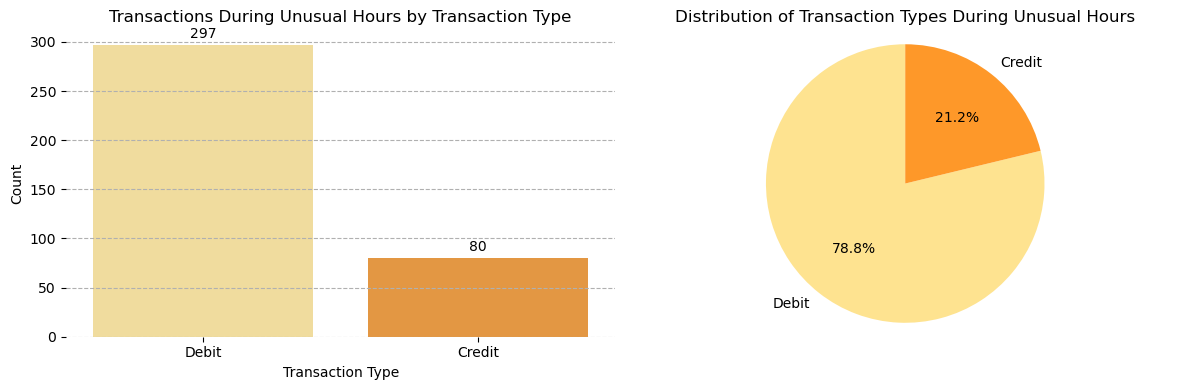

In [53]:
## What is the distribution of transaction types (credit/debit) for transactions that occurred during unusual hours?
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = sns.countplot(data=unusual_hour_transactions, x='TransactionType', palette=custom_palette, ax=axes[0])
axes[0].set_title('Transactions During Unusual Hours by Transaction Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5), textcoords='offset points')
sns.despine(left=True, bottom=True)

transaction_counts = unusual_hour_transactions['TransactionType'].value_counts()
axes[1].pie(transaction_counts, labels=transaction_counts.index, autopct='%1.1f%%', startangle=90, colors=custom_palette)
axes[1].set_title('Distribution of Transaction Types During Unusual Hours')
axes[1].axis('equal')  

plt.tight_layout() 
plt.show()

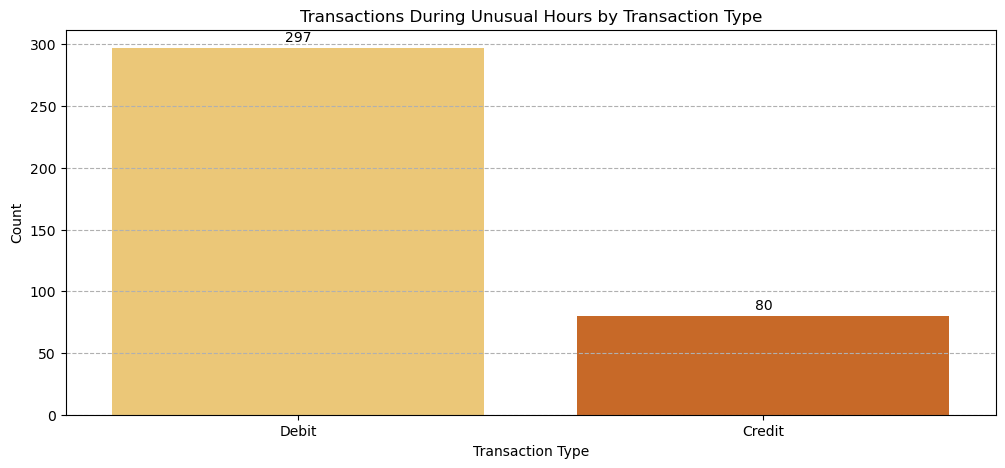

In [54]:
# Visualize transactions during unusual hours by type
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=unusual_hour_transactions, x='TransactionType', palette='YlOrBr') 
plt.title('Transactions During Unusual Hours by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--')

for p in ax.patches:  
    ax.annotate(f'{int(p.get_height())}',  
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='baseline',  
                color='black', fontsize=10,
                xytext=(0, 5), textcoords='offset points')

plt.show()

In [55]:
## How many transactions are included in the rapid transactions?

In [56]:
# Ensure TransactionDate is in datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Sort data by AccountID and TransactionDate for accurate time difference calculations
df_sorted = df.sort_values(by=['AccountID', 'TransactionDate'])

# Calculate time difference between consecutive transactions for each account
df_sorted['TimeDifference'] = df_sorted.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds()

# Filter transactions with a time difference of less than 1 hour (3600 seconds)
rapid_transactions = df_sorted[df_sorted['TimeDifference'] <= 3600]

# Display the number of such transactions and a preview of the data
print(f"Number of transactions with time difference of less than 1 hour: {len(rapid_transactions)}")
display(rapid_transactions.head())

Number of transactions with time difference of less than 1 hour: 16


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour,TimeDifference
95,TX000096,AC00010,508.68,2023-06-26 16:16:50,Credit,Mesa,D000622,193.108.17.115,M048,Branch,51,Engineer,127,1,7708.41,2024-11-04 08:09:32,8217.09,Monday,16,505.0
1258,TX001259,AC00020,603.23,2023-08-24 17:34:13,Debit,Detroit,D000238,38.210.156.148,M017,Branch,28,Student,48,1,117.98,2024-11-04 08:08:18,-485.25,Thursday,17,2812.0
2497,TX002498,AC00030,348.17,2023-05-10 17:56:31,Debit,El Paso,D000269,82.51.236.134,M072,ATM,21,Student,181,1,1887.84,2024-11-04 08:11:06,1539.67,Wednesday,17,394.0
496,TX000497,AC00114,286.50,2023-10-23 16:58:04,Credit,Boston,D000602,16.128.130.153,M097,Branch,30,Engineer,60,1,8517.95,2024-11-04 08:09:17,8804.45,Monday,16,451.0
2341,TX002342,AC00144,97.73,2023-05-29 17:55:23,Debit,Sacramento,D000038,135.29.211.116,M018,Branch,69,Doctor,156,1,7885.21,2024-11-04 08:08:27,7787.48,Monday,17,2480.0


In [57]:
## How many transactions are included in the unusually high-value transactions? 


In [58]:
# Calculate average transaction amount per account
account_avg = df.groupby('AccountID')['TransactionAmount'].mean().reset_index().rename(columns={'TransactionAmount': 'AverageTransactionAmount'})
df = df.merge(account_avg, on='AccountID')
# Identify transactions that are 3 times above the average for the account
unusual_transactions = df[df['TransactionAmount'] > (df['AverageTransactionAmount'] * 3)]
print(f"Number of unusually high-value transactions: {len(unusual_transactions)}")
display(unusual_transactions.head())

Number of unusually high-value transactions: 62


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour,AverageTransactionAmount
60,TX000061,AC00438,568.52,2023-10-06 18:44:37,Debit,Indianapolis,D000233,27.143.109.203,M094,ATM,46,Engineer,152,1,5499.91,2024-11-04 08:06:25,4931.39,Friday,18,165.691250
129,TX000130,AC00320,1036.66,2023-07-11 16:39:53,Debit,San Antonio,D000015,53.218.177.171,M062,Branch,58,Doctor,144,1,5541.57,2024-11-04 08:09:24,4504.91,Tuesday,16,335.652000
141,TX000142,AC00114,1049.92,2023-10-23 16:50:33,Debit,Detroit,D000522,121.67.144.20,M052,ATM,80,Retired,21,1,2037.85,2024-11-04 08:10:34,987.93,Monday,16,317.322857
176,TX000177,AC00363,1362.55,2023-02-10 18:07:07,Debit,El Paso,D000213,93.52.44.101,M001,ATM,29,Engineer,106,1,2429.68,2024-11-04 08:11:05,1067.13,Friday,18,391.909167
190,TX000191,AC00396,1422.55,2023-07-10 17:49:18,Debit,Washington,D000569,188.124.181.12,M072,Branch,79,Retired,165,1,5674.32,2024-11-04 08:06:50,4251.77,Monday,17,410.837500


In [59]:
## What is the shape of the distribution of unusually high-value transaction amounts?

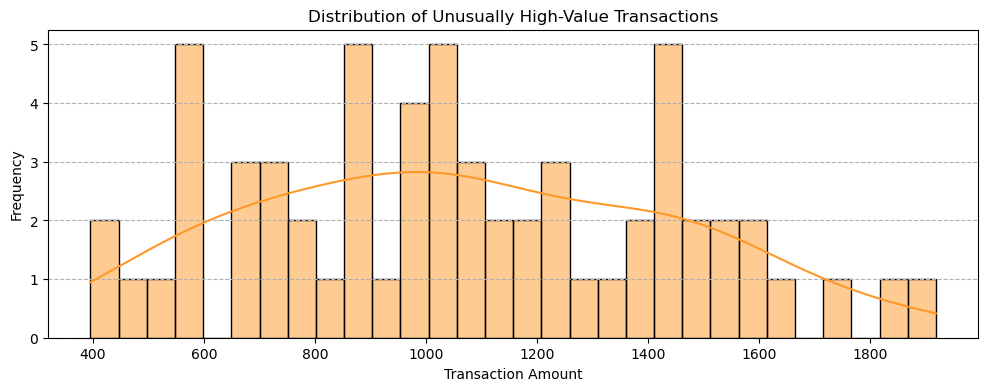

In [60]:
# Plot unusually high transactions
plt.figure(figsize=(12, 4))
sns.histplot(unusual_transactions['TransactionAmount'], bins=30, kde=True, color=sns.color_palette("YlOrBr", 1)[0]) 
plt.title('Distribution of Unusually High-Value Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency') 
plt.grid(axis='y', linestyle='--')  
plt.show()

In [61]:
## Which channel has the highest proportion of credit transactions? Which has the highest proportion of debit transactions?

In [62]:

# Analyze fraud likelihood by channel and transaction type
channel_analysis = df.groupby(['Channel', 'TransactionType'])['TransactionID'].count().reset_index()
channel_analysis.columns = ['Channel', 'TransactionType', 'Count']
print(channel_analysis)

  Channel TransactionType  Count
0     ATM          Credit     73
1     ATM           Debit    760
2  Branch          Credit    251
3  Branch           Debit    617
4  Online          Credit    244
5  Online           Debit    567


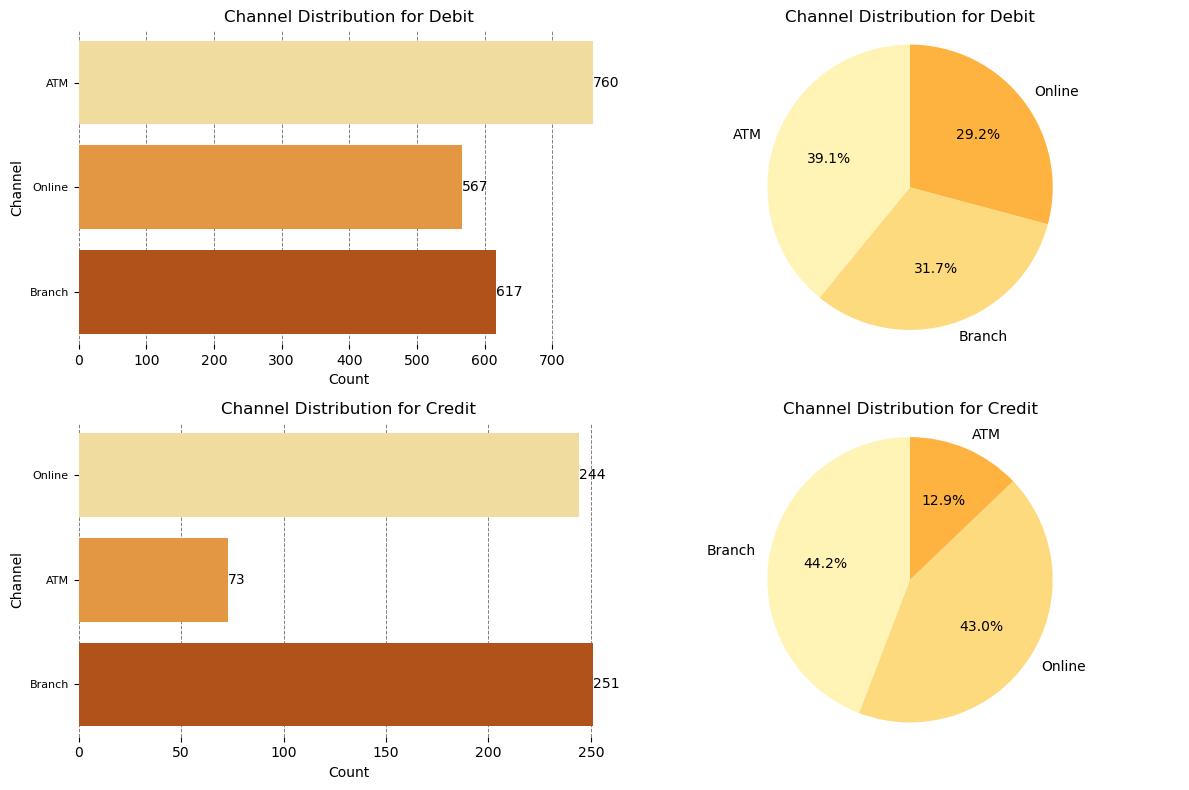

In [63]:
def plot_channel_transaction_visualization(ax, df, transaction_type):
    filtered_data = df[df['TransactionType'] == transaction_type]

    # Count Plot
    sns.countplot(y='Channel', data=filtered_data, ax=ax[0], palette='YlOrBr')
    ax[0].set_title(f'Channel Distribution for {transaction_type}')
    ax[0].set_xlabel('Count')
    ax[0].set_ylabel('Channel')
    ax[0].tick_params(axis='y', labelsize=8) 

    for p in ax[0].patches:
        ax[0].annotate(f'{int(p.get_width())}',
                        (p.get_width(), p.get_y() + p.get_height() / 2),
                        ha='left', va='center',
                        color='black', fontsize=10)

    ax[0].set_axisbelow(True)
    ax[0].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)
    sns.despine(left=True, bottom=True)

    # Pie Chart
    channel_counts = filtered_data['Channel'].value_counts()
    ax[1].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('YlOrBr'))
    ax[1].set_title(f'Channel Distribution for {transaction_type}')
    ax[1].axis('equal')  

unique_transaction_types = df['TransactionType'].unique()
num_transaction_types = len(unique_transaction_types)

fig, axes = plt.subplots(num_transaction_types, 2, figsize=(12, 4 * num_transaction_types))

for i, transaction_type in enumerate(unique_transaction_types):
    plot_channel_transaction_visualization(axes[i], df, transaction_type)

plt.tight_layout()
plt.show()

In [64]:
## How many merchants are included in the "outlier" merchants? 


In [65]:
# Calculate merchant statistics
merchant_stats = df.groupby('MerchantID')['TransactionAmount'].agg(
    TotalTransactions='count',
    AverageTransactionAmount='mean',
    MaxTransactionAmount='max',
    StdTransactionAmount='std'
).reset_index()

# Define criteria for outliers
overall_std = df['TransactionAmount'].std()
overall_mean = df['TransactionAmount'].mean()

high_std_merchants = merchant_stats[merchant_stats['StdTransactionAmount'] > overall_std]
high_value_merchants = merchant_stats[merchant_stats['MaxTransactionAmount'] > (overall_mean * 3)]
high_transaction_count_merchants = merchant_stats[merchant_stats['TotalTransactions'] > merchant_stats['TotalTransactions'].quantile(0.95)]

# Combine criteria
outlier_merchants = pd.concat([high_std_merchants, high_value_merchants, high_transaction_count_merchants]).drop_duplicates()

# Visualize and analyze
print(f"Number of identified outlier merchants: {len(outlier_merchants)}")
display(outlier_merchants)

Number of identified outlier merchants: 66


,MerchantID,TotalTransactions,AverageTransactionAmount,MaxTransactionAmount,StdTransactionAmount
3,M004,31,265.268387,1309.79,348.948133
4,M005,32,346.872813,1168.26,314.297555
5,M006,16,383.873125,1154.79,309.952846
8,M009,30,350.868000,1162.42,346.133895
11,M012,21,409.340952,1831.02,453.717576
...,...,...,...,...,...
67,M068,32,302.502187,1192.95,249.361991
86,M087,25,227.976400,1020.73,264.217926
87,M088,30,300.054333,1454.52,276.328185
89,M090,24,175.532500,1076.98,241.480707


In [66]:
## What is the total number of accounts that are linked to these suspicious devices?

In [67]:
# Multiple Accounts Using the Same Device
# Count unique accounts per DeviceID
device_account_counts = df.groupby('DeviceID')['AccountID'].nunique().reset_index().rename(columns={'AccountID': 'UniqueAccounts'})
# Identify devices associated with more than one account
suspicious_devices = device_account_counts[device_account_counts['UniqueAccounts'] > 1]
print(f"Number of devices used for multiple accounts: {len(suspicious_devices)}")
display(suspicious_devices)

Number of devices used for multiple accounts: 609


,DeviceID,UniqueAccounts
0,D000001,4
1,D000002,5
2,D000003,2
3,D000004,4
4,D000005,6
...,...,...
676,D000696,2
677,D000697,9
678,D000698,3
679,D000699,2


In [68]:
## What is the most common number of unique accounts per device?

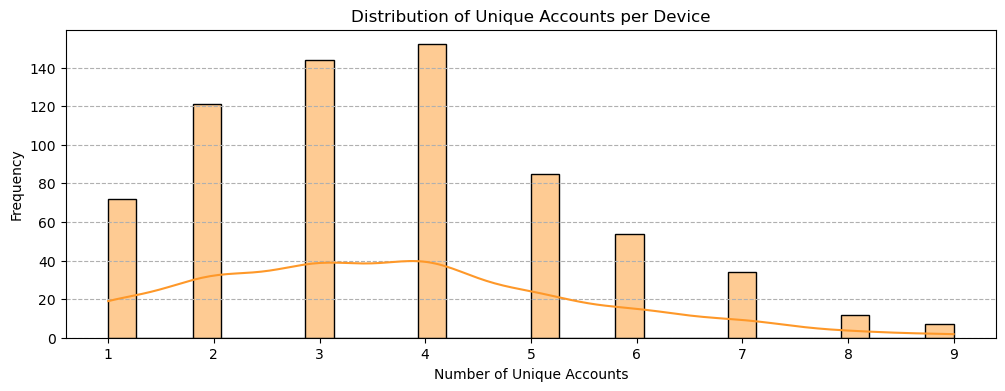

In [69]:
# Visualize the distribution
plt.figure(figsize=(12, 4))
sns.histplot(device_account_counts['UniqueAccounts'], bins=30, kde=True, color=sns.color_palette("YlOrBr", 1)[0]) 
plt.title('Distribution of Unique Accounts per Device')
plt.xlabel('Number of Unique Accounts')
plt.ylabel('Frequency') 
plt.grid(axis='y', linestyle='--') 
plt.show()

In [70]:
## What is the range of unique account counts associated with these shared IP addresses?

In [71]:
# Multiple Accounts Using the Same IP Address
ip_counts = df.groupby('IP Address')['AccountID'].nunique().reset_index()
ip_counts.columns = ['IP Address', 'UniqueAccounts']
shared_ips = ip_counts[ip_counts['UniqueAccounts'] > 1]
print(f"Number of IP addresses used by multiple accounts: {len(shared_ips)}")
display(shared_ips.head())

Number of IP addresses used by multiple accounts: 552


,IP Address,UniqueAccounts
0,1.198.76.182,8
1,1.238.163.61,3
2,1.7.29.72,2
3,1.98.25.114,3
4,10.144.131.89,3


In [72]:
## What is the maximum number of unique accounts associated with a single IP address in this top 15 list? 

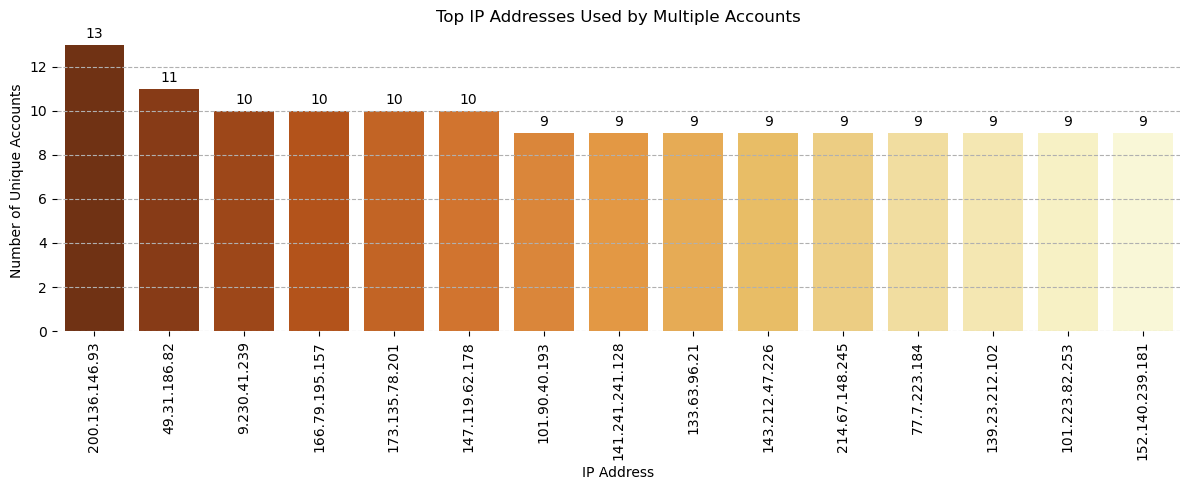

In [73]:
# Top IP addresses used by multiple accounts
plt.figure(figsize=(12, 5))
top_shared_ips = shared_ips.sort_values(by='UniqueAccounts', ascending=False).head(15)

ax = sns.barplot(x=top_shared_ips['IP Address'], y=top_shared_ips['UniqueAccounts'], palette='YlOrBr_r')  
plt.title('Top IP Addresses Used by Multiple Accounts')
plt.xlabel('IP Address')
plt.ylabel('Number of Unique Accounts')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',  
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='baseline',  
                color='black', fontsize=10,
                xytext=(0, 5), textcoords='offset points')  

sns.despine(left=True, bottom=True) 

plt.tight_layout() 
plt.show()

In [74]:
## How many accounts are included in the high_ip_variability_accounts DataFrame?

In [75]:
# Frequent IP Changes for a Single Account
# Group by AccountID to count unique IP Addresses
ip_variability = df.groupby('AccountID')['IP Address'].nunique().reset_index().rename(columns={'IP Address': 'UniqueIPAddresses'})
# Identify accounts with a high number of unique IP Addresses
high_ip_variability_accounts = ip_variability[ip_variability['UniqueIPAddresses'] > 3]  # Example threshold
print(f"Number of accounts with high IP variability: {len(high_ip_variability_accounts)}")
display(high_ip_variability_accounts)

Number of accounts with high IP variability: 366


,AccountID,UniqueIPAddresses
1,AC00002,7
2,AC00003,5
3,AC00004,9
4,AC00005,9
5,AC00006,4
...,...,...
489,AC00495,8
491,AC00497,6
492,AC00498,8
493,AC00499,7


In [76]:
## What is the range of durations for these long duration transactions?

In [77]:
# Calculate summary statistics for TransactionDuration
duration_mean = df['TransactionDuration'].mean()
duration_std = df['TransactionDuration'].std()
long_duration_threshold = duration_mean + 2 * duration_std

# Identify long-duration transactions
long_duration_transactions = df[df['TransactionDuration'] > long_duration_threshold]
print(f"Number of long-duration transactions (above {long_duration_threshold} seconds): {len(long_duration_transactions)}")
display(long_duration_transactions.head())

Number of long-duration transactions (above 259.5708259512189 seconds): 142


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour,AverageTransactionAmount
7,TX000008,AC00069,171.42,2023-05-08 17:47:59,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,2024-11-04 08:10:55,2967.66,Monday,17,231.082857
25,TX000026,AC00041,7.49,2023-10-20 17:53:13,Credit,Houston,D000671,81.248.235.147,M043,Online,65,Retired,276,1,3634.67,2024-11-04 08:09:44,3642.16,Friday,17,164.240000
29,TX000030,AC00313,56.17,2023-09-20 16:55:42,Debit,Detroit,D000297,33.28.138.82,M043,Branch,27,Student,283,1,1351.69,2024-11-04 08:08:30,1295.52,Wednesday,16,247.900000
51,TX000052,AC00482,424.56,2023-02-21 17:45:55,Debit,Omaha,D000598,179.43.245.131,M015,Online,51,Engineer,264,1,5183.85,2024-11-04 08:09:02,4759.29,Tuesday,17,265.671667
73,TX000074,AC00110,233.92,2023-10-20 16:54:28,Credit,Jacksonville,D000295,152.140.239.181,M046,Online,26,Student,280,1,6537.62,2024-11-04 08:08:45,6771.54,Friday,16,313.471250


In [78]:
## What is the overall shape of the transaction duration distribution?

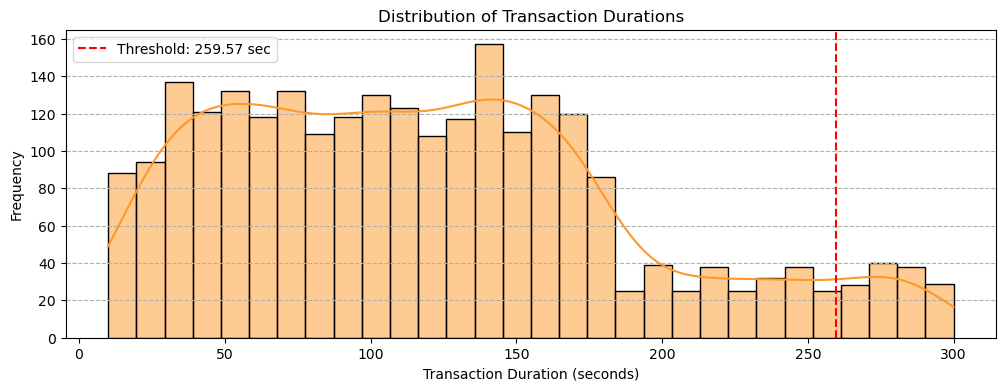

In [79]:
# Visualize distribution of TransactionDuration
plt.figure(figsize=(12, 4))
sns.histplot(df['TransactionDuration'], bins=30, kde=True, color=sns.color_palette("YlOrBr", 1)[0])  # Color Palette
plt.axvline(long_duration_threshold, color='red', linestyle='--', label=f'Threshold: {long_duration_threshold:.2f} sec') 
plt.title('Distribution of Transaction Durations')
plt.xlabel('Transaction Duration (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--')  
plt.show()

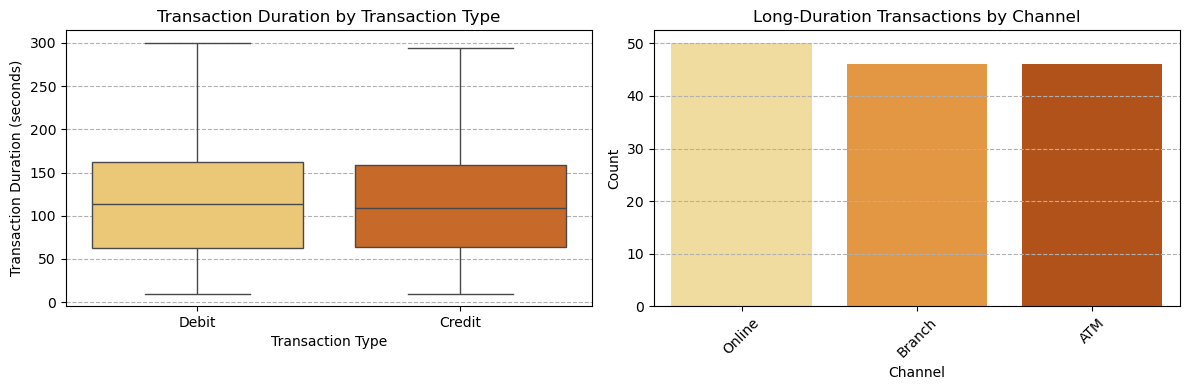

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

# Boxplot of Transaction Duration by Transaction Type
sns.boxplot(ax=axes[0], x='TransactionType', y='TransactionDuration', data=df, palette='YlOrBr')
axes[0].set_title('Transaction Duration by Transaction Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Transaction Duration (seconds)')
axes[0].grid(axis='y', linestyle='--')  

# Countplot of Long-Duration Transactions by Channel
channel_order = long_duration_transactions['Channel'].value_counts().index
sns.countplot(ax=axes[1], data=long_duration_transactions, x='Channel', order=channel_order, palette='YlOrBr')
axes[1].set_title('Long-Duration Transactions by Channel')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--')  

plt.tight_layout()  
plt.show()

##### Anomaly Detection

**Anomaly detection is a crucial aspect of fraud prevention, as it helps identify transactions that deviate significantly from normal patterns. In this section, we will explore three methods for anomaly detection:**
* **K-means clustering,** 
* **DBSCAN (Density-Based Spatial Clustering of Applications with Noise),** and 
* **Isolation Forest.**

In [81]:
# Select features for clustering
features = ['TransactionAmount', 'TransactionDuration'] 
X = df[features].copy()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)  # Test for clusters from 1 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


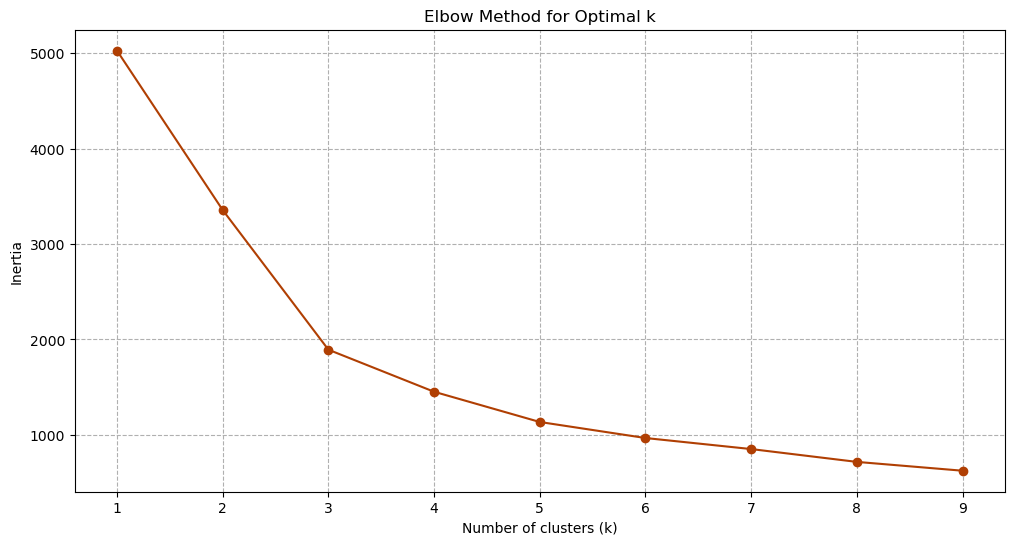

In [82]:
# Plot the Elbow Method
plt.figure(figsize=(12, 6))
plt.plot(K, inertia, marker='o', linestyle='-', color=sns.color_palette("YlOrBr", 10)[8])  
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, linestyle='--')  
plt.show()

In [83]:
# Fit K-means with the chosen number of clusters (k=3)
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)

# Assign clusters and calculate distance to cluster centroid
df['Cluster'] = kmeans.labels_
df['DistanceToCentroid'] = np.linalg.norm(X_scaled - kmeans.cluster_centers_[kmeans.labels_], axis=1)

# Identify potential frauds based on distance threshold
threshold = df['DistanceToCentroid'].quantile(0.95)
potential_frauds = df[df['DistanceToCentroid'] > threshold]

print(f"Number of potential frauds detected: {len(potential_frauds)}")
display(potential_frauds)

Number of potential frauds detected: 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour,AverageTransactionAmount,Cluster,DistanceToCentroid
74,TX000075,AC00265,1212.51,2023-10-04 16:36:29,Debit,Indianapolis,D000231,193.83.0.183,M036,Branch,...,24,1,605.95,2024-11-04 08:06:51,-606.56,Wednesday,16,439.288889,0,1.876727
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,Austin,D000574,165.114.224.47,M012,Online,...,30,1,8654.28,2024-11-04 08:06:53,9994.47,Friday,17,642.514000,0,2.163279
141,TX000142,AC00114,1049.92,2023-10-23 16:50:33,Debit,Detroit,D000522,121.67.144.20,M052,ATM,...,21,1,2037.85,2024-11-04 08:10:34,987.93,Monday,16,317.322857,0,1.562140
142,TX000143,AC00163,227.14,2023-07-03 17:42:08,Debit,Charlotte,D000439,197.162.55.147,M057,ATM,...,294,1,341.94,2024-11-04 08:11:34,114.80,Monday,17,307.955000,2,1.521390
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,...,296,1,2042.22,2024-11-04 08:11:44,1068.83,Wednesday,17,591.600000,0,2.640557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2403,TX002404,AC00111,1493.00,2023-06-07 17:05:41,Debit,Colorado Springs,D000344,136.162.111.135,M096,ATM,...,151,1,1619.16,2024-11-04 08:07:07,126.16,Wednesday,17,438.818571,0,2.368753
2414,TX002415,AC00028,1664.33,2023-09-25 17:11:19,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,...,65,1,1588.31,2024-11-04 08:07:07,-76.02,Monday,17,723.390000,0,2.986511
2439,TX002440,AC00439,538.17,2023-09-26 17:27:17,Credit,Washington,D000430,116.44.12.250,M055,Branch,...,252,1,5908.04,2024-11-04 08:10:25,6446.21,Tuesday,17,465.090000,2,1.490003
2445,TX002446,AC00439,403.01,2023-09-04 17:32:35,Debit,Washington,D000677,223.32.70.156,M029,Online,...,286,3,10513.52,2024-11-04 08:09:32,10110.51,Monday,17,465.090000,2,1.573122


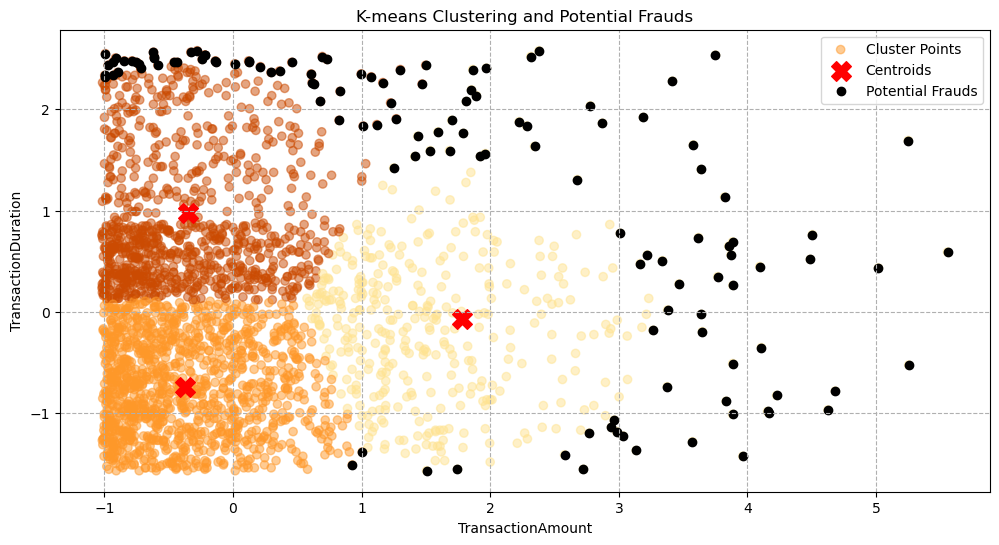

In [84]:
# Visualize clusters and potential frauds (2D plot for simplicity with legend)
plt.figure(figsize=(12, 6))

cluster_colors = sns.color_palette("YlOrBr", n_colors=len(np.unique(kmeans.labels_)))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=[cluster_colors[i] for i in kmeans.labels_], alpha=0.5, label='Cluster Points')
centroids = plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')

frauds = plt.scatter(X_scaled[potential_frauds.index, 0], X_scaled[potential_frauds.index, 1], c='black', label='Potential Frauds', edgecolors='k')

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('K-means Clustering and Potential Frauds')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.show()

* **Cluster Formation:** The plot shows three distinct clusters formed by the K-means algorithm. The clusters appear to be relatively well-separated, indicating that K-means has effectively grouped similar transactions together.

* **Potential Frauds:** The black points represent the transactions identified as potential frauds based on their distance from the cluster centroids. These points are generally located away from the main cluster densities and appear to be outliers.

* **Cluster Characteristics:** 
    * **Cluster 1 (Yellow):** This cluster appears to contain the majority of transactions and seems to represent typical, normal transactions.
    * **Cluster 2 (Orange):** This cluster might represent transactions with moderate amounts and durations.
    * **Cluster 3 (Brown):** This cluster could potentially represent transactions with higher amounts and/or longer durations.

* **Distance Threshold:** The threshold for identifying potential frauds is set at the 95th percentile of the distances to the cluster centroids. This means that only transactions with distances greater than the 95th percentile are considered potential frauds.

* **Number of Potential Frauds:** The code identifies 126 transactions as potential frauds based on the distance threshold.

**Overall, the K-means clustering analysis has effectively identified a set of transactions that deviate significantly from the typical transaction patterns.** 

## DBSCAN Clustering for Anomaly Detection 🧩

In [85]:
# Map the cluster labels to descriptive names
label_mapping = {
    -1: 'Fraud (Outliers)',  
    0: 'Normal',
    1: 'Suspicious Group 1',
    2: 'Suspicious Group 2',
    3: 'Suspicious Group 3',
    4: 'Suspicious Group 4',
}

# Select relevant features for DBSCAN 
features = ['TransactionAmount', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']
X = df[features].copy()

X = X.fillna(X.mean())

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  
dbscan.fit(X_scaled)

df['DBSCAN_Cluster'] = dbscan.labels_

# Map cluster labels to descriptive names
df['Cluster_Description'] = df['DBSCAN_Cluster'].map(label_mapping)

# Identify outliers (noise points) labeled as -1
potential_frauds = df[df['DBSCAN_Cluster'] == -1]
print(f"Number of potential frauds detected by DBSCAN: {len(potential_frauds)}")
display(potential_frauds.head())


Number of potential frauds detected by DBSCAN: 17


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,AccountBalance,PreviousTransactionDate,BalanceChange,Day_of_Week,TransactionHour,AverageTransactionAmount,Cluster,DistanceToCentroid,DBSCAN_Cluster,Cluster_Description
274,TX000275,AC00454,1176.28,2023-12-20 16:08:02,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,...,323.69,2024-11-04 08:11:44,1499.97,Wednesday,16,494.182500,0,1.488559,-1,Fraud (Outliers)
454,TX000455,AC00264,611.11,2023-10-18 18:32:31,Debit,Detroit,D000215,141.201.46.191,M045,ATM,...,919.84,2024-11-04 08:11:12,308.73,Wednesday,18,441.255000,2,1.959599,-1,Fraud (Outliers)
653,TX000654,AC00423,1919.11,2023-06-27 17:48:25,Debit,Portland,D000191,207.157.126.125,M033,ATM,...,11090.24,2024-11-04 08:10:27,9171.13,Tuesday,17,506.356667,0,3.828962,-1,Fraud (Outliers)
693,TX000694,AC00011,733.29,2023-03-15 18:42:16,Debit,Virginia Beach,D000618,16.51.235.240,M032,ATM,...,10427.00,2024-11-04 08:07:12,9693.71,Wednesday,18,348.322857,0,0.418493,-1,Fraud (Outliers)
754,TX000755,AC00153,84.34,2023-06-08 16:27:56,Debit,Memphis,D000493,200.136.146.93,M039,Online,...,5313.97,2024-11-04 08:09:31,5229.63,Thursday,16,350.270000,2,0.940290,-1,Fraud (Outliers)


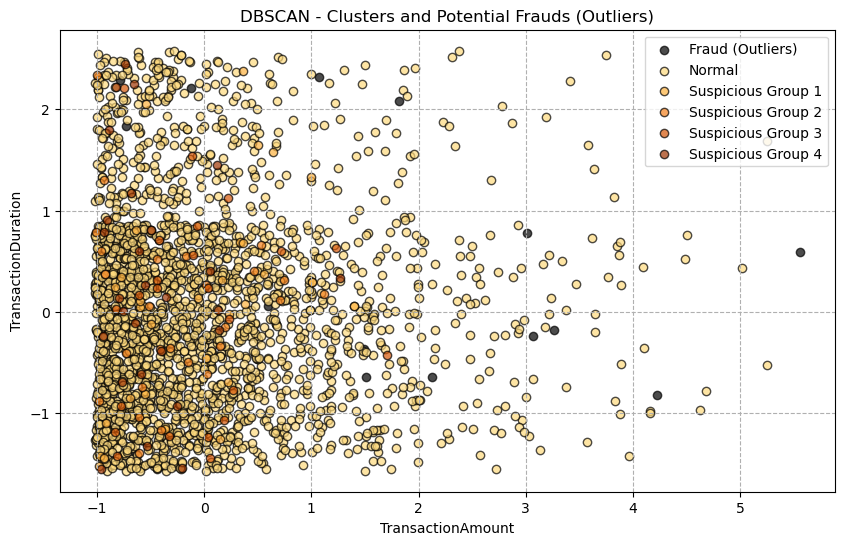

In [86]:
# Visualize clusters and potential frauds
plt.figure(figsize=(10, 6))
unique_labels = np.unique(dbscan.labels_)

cluster_colors = sns.color_palette("YlOrBr", n_colors=len(unique_labels)) 

colors = []
for i, k in enumerate(unique_labels):
    if k == -1:
        colors.append([0, 0, 0, 1])  # Black for noise
    else:
        colors.append(cluster_colors[i % len(cluster_colors)])  

for k, col in zip(unique_labels, colors):
    class_member_mask = (dbscan.labels_ == k)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], color=col, edgecolor='k', alpha=0.7, label=label_mapping.get(k, f'Cluster {k}'))

plt.title('DBSCAN - Clusters and Potential Frauds (Outliers)')
plt.xlabel(features[0])  # TransactionAmount
plt.ylabel(features[1])  # TransactionDuration
plt.legend()
plt.grid(True, linestyle='--')  
plt.show()

* **Cluster Formation:** The plot shows several distinct clusters of transactions, indicating that DBSCAN has effectively grouped similar transactions together. 
* **Potential Frauds (Outliers):** The black points represent the transactions identified as potential frauds (outliers) by DBSCAN. These points are scattered across the plot, suggesting that they deviate significantly from the density of any cluster.
* **Suspicious Groups:** DBSCAN has also identified several "Suspicious Groups" (colored clusters). These groups might represent transactions with specific characteristics that warrant further investigation, even though they are not considered outliers.

* **Feature Scaling:** Standardizing the features using `StandardScaler` ensures that all features have a similar scale, which is crucial for DBSCAN to work effectively.
* **Outlier Detection:** DBSCAN identifies potential frauds (outliers) as points that have low density in their local neighborhood.
* **Number of Potential Frauds:** The code identifies 17 transactions as potential frauds based on DBSCAN's outlier detection.

**Overall, the DBSCAN clustering analysis has effectively identified a set of transactions that deviate significantly from the typical transaction patterns and appear to be outliers.** 


## Isolation Forest for Anomaly Detection 🌲

In [87]:
# Define outlier mapping
outlier_mapping = {1: 'Normal', -1: 'Potential Fraud'}

# Select relevant features for fraud detection
features = ['TransactionAmount', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']  # Modify as needed
X = df[features].copy()

X = X.fillna(X.mean())

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the Isolation Forest model
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# Predict anomalies
df['AnomalyScore'] = iso_forest.decision_function(X_scaled)
df['IsAnomaly'] = iso_forest.predict(X_scaled)  

# Map results to descriptive labels
df['AnomalyLabel'] = df['IsAnomaly'].map(outlier_mapping)

# Filter out detected anomalies
potential_frauds = df[df['IsAnomaly'] == -1]
print(f"Number of potential frauds detected: {len(potential_frauds)}")
display(potential_frauds.head())

Number of potential frauds detected: 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,Day_of_Week,TransactionHour,AverageTransactionAmount,Cluster,DistanceToCentroid,DBSCAN_Cluster,Cluster_Description,AnomalyScore,IsAnomaly,AnomalyLabel
26,TX000027,AC00441,246.93,2023-04-17 16:37:01,Debit,Miami,D000046,55.154.161.250,M029,ATM,...,Monday,16,317.948333,2,0.461840,2,Suspicious Group 2,-0.075150,-1,Potential Fraud
32,TX000033,AC00060,396.45,2023-09-25 16:26:00,Debit,New York,D000621,133.67.250.163,M007,ATM,...,Monday,16,388.180000,2,0.744993,1,Suspicious Group 1,-0.014181,-1,Potential Fraud
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,Austin,D000574,165.114.224.47,M012,Online,...,Friday,17,642.514000,0,2.163279,0,Normal,-0.018206,-1,Potential Fraud
91,TX000092,AC00310,223.85,2023-10-02 16:36:10,Debit,Kansas City,D000481,133.223.159.151,M009,ATM,...,Monday,16,439.977143,1,0.221557,4,Suspicious Group 4,-0.029888,-1,Potential Fraud
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,...,Wednesday,17,591.600000,0,2.640557,0,Normal,-0.016904,-1,Potential Fraud


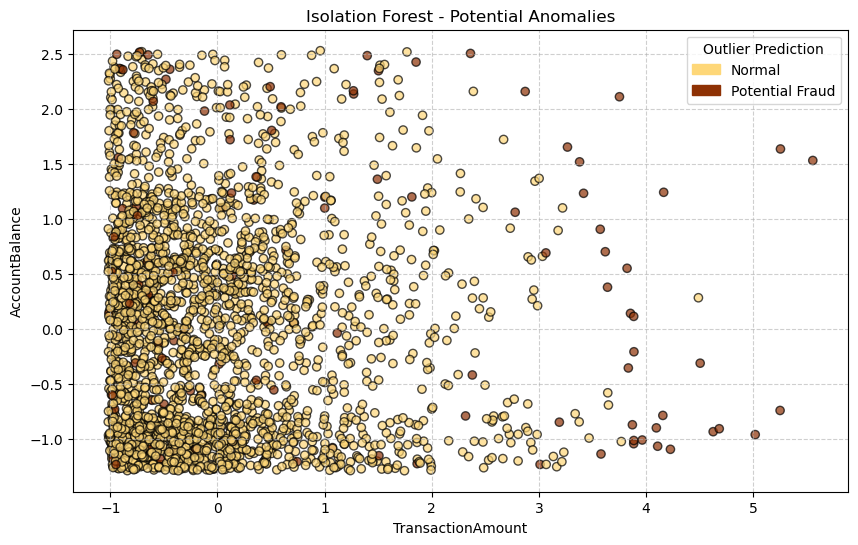

In [88]:
cmap = plt.get_cmap('YlOrBr')
colors = np.array([cmap(0.9) if anomaly == -1 else cmap(0.3) for anomaly in df['IsAnomaly']])

# Visualize potential frauds (TransactionAmount vs AccountBalance)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_scaled[:, 0],  # TransactionAmount 
    X_scaled[:, 2],  # AccountBalance 
    c=colors, 
    alpha=0.7, 
    edgecolors='k', 
    label='Data Points'
)

normal_patch = mpatches.Patch(color=cmap(0.3), label='Normal')
fraud_patch = mpatches.Patch(color=cmap(0.9), label='Potential Fraud')
plt.legend(handles=[normal_patch, fraud_patch], title='Outlier Prediction')

plt.title('Isolation Forest - Potential Anomalies')
plt.xlabel(features[0])  
plt.ylabel(features[2])  

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* **Anomaly Detection:** The plot effectively visualizes the Isolation Forest's ability to identify anomalies. The points colored in a darker shade represent the transactions identified as potential frauds. These points are generally scattered across the plot, indicating that they deviate significantly from the majority of the data points.

* **Normal Transactions:** The majority of data points are colored in a lighter shade, representing normal transactions. These points cluster together, suggesting that they exhibit typical transaction behavior.

* **Feature Space:** The plot shows the distribution of transactions in the "TransactionAmount" and "AccountBalance" feature space. This visualization helps to understand how these features contribute to the identification of anomalies.

* **Anomaly Score and Prediction:** The `decision_function` provides an anomaly score for each data point. The `predict` method assigns a label of 1 to normal data points and -1 to anomalies.

* **Number of Potential Frauds:** The code identifies 126 transactions as potential frauds based on the Isolation Forest model's predictions.

**Overall, the Isolation Forest has effectively identified a set of transactions that deviate significantly from the typical transaction patterns.** 


**Generate Fraud Risk Probability per Transaction**

In [89]:
# Normalize the anomaly scores to a 0–100 Fraud Risk Score
df['Fraud_Risk_Score'] = (1 - (df['AnomalyScore'] - df['AnomalyScore'].min()) /
                          (df['AnomalyScore'].max() - df['AnomalyScore'].min())) * 100

# Round for readability
df['Fraud_Risk_Score'] = df['Fraud_Risk_Score'].round(2)


**Normalize the Probability into a 0–100 Score**

In [90]:
fraud_risk_index = df.groupby('AccountID')['Fraud_Risk_Score'].mean().reset_index()
fraud_risk_index.rename(columns={'Fraud_Risk_Score': 'Avg_Fraud_Risk_Index'}, inplace=True)

overall_fraud_risk = fraud_risk_index['Avg_Fraud_Risk_Index'].mean()
print("Overall Institutional Fraud Risk:", round(overall_fraud_risk, 2))


Overall Institutional Fraud Risk: 20.99


In [91]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TransactionHour,AverageTransactionAmount,Cluster,DistanceToCentroid,DBSCAN_Cluster,Cluster_Description,AnomalyScore,IsAnomaly,AnomalyLabel,Fraud_Risk_Score
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,16,460.698571,1,0.627683,0,Normal,0.184358,1,Normal,6.92
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,16,304.622857,2,0.912412,0,Normal,0.097301,1,Normal,33.36
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,18,237.047500,1,0.276223,0,Normal,0.178514,1,Normal,8.70
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,16,236.483750,1,0.616155,0,Normal,0.150973,1,Normal,17.06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,17,280.796667,2,0.639987,0,Normal,0.142493,1,Normal,19.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,...,17,273.373000,0,0.157098,0,Normal,0.044795,1,Normal,49.31
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,...,17,340.741111,2,0.247123,0,Normal,0.143192,1,Normal,19.42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,...,17,397.733750,2,0.827269,0,Normal,0.175343,1,Normal,9.66
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,...,16,312.650000,1,0.701808,0,Normal,0.134966,1,Normal,21.92


In [92]:
df.to_csv("final_fraud_risk_dataset.csv", index=False)

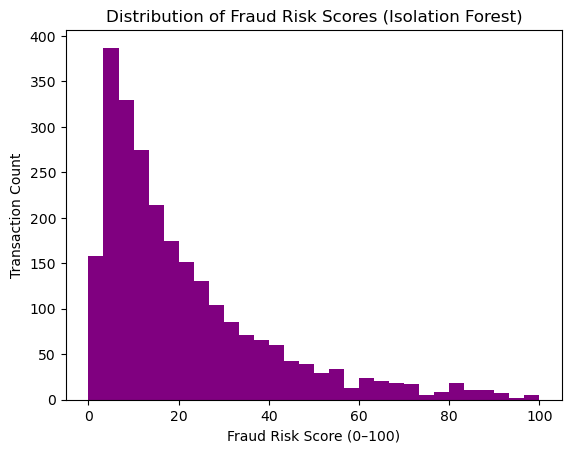

In [93]:
import matplotlib.pyplot as plt
plt.hist(df['Fraud_Risk_Score'], bins=30, color='purple')
plt.title('Distribution of Fraud Risk Scores (Isolation Forest)')
plt.xlabel('Fraud Risk Score (0–100)')
plt.ylabel('Transaction Count')
plt.show()


In [94]:
import joblib

# model = the full pipeline (preprocessing + classifier)
joblib.dump(iso_forest, "Fraud_risk_model.pkl")

print("Model saved successfully!")

Model saved successfully!
